In [25]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import geopandas as gpd

In [26]:
from pointpats import Window, PoissonPointProcess, PoissonClusterPointProcess #as_window
import libpysal as ps
from shapely.geometry import Point, Polygon, box, mapping
import json

In [27]:
import datetime

In [28]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

# Red -> peach -> light cyan -> cyan -> blue (like your figure)
ocean_stage = LinearSegmentedColormap.from_list(
    "ocean_stage",
    [
        "#b50027",  # deep red
        "#ff0026",  # red
        "#f7845e",  # coral
        "#efcdb3",  # peach
        "#89c5d0",  # light cyan
        "#40b3ce",  # cyan
        "#2491bf",  # blue-cyan
        "#195ea1"   # deep blue
    ],
    N=512
)

mpl.colormaps.register(ocean_stage, force=True)


In [29]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

# Red -> peach -> light cyan -> cyan -> blue (like your figure)
ocean_stage = LinearSegmentedColormap.from_list(
    "ocean_stage2",
    [
        "#195ea1",   # deep blue
        "#649cc7",  # blue-cyan
        "#a2cae0",  # cyan
        "#d5e9e2",  # light cyan
        "#fcf9cf",  # peach
        "#fbd39f",  # coral
        "#f19e7a",  # red
        "#e0585e"  # deep red       
    ],
    N=512
)

mpl.colormaps.register(ocean_stage, force=True)


In [30]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

soft_div = LinearSegmentedColormap.from_list(
    "greenpink",
    [
        "#168d15", "#39972d", "#82b677", "#b4cfb3",
        "#dfe9df", "#f7f7f7", "#f2d8d6", "#e29d95", "#db8179"
    ],
    N=512  # more levels
)

mpl.colormaps.register(soft_div, force=True)


# DGP

In [31]:
seed = 0

square = Polygon([Point((0, 0)), Point((0, 80)), Point((80, 80)), Point((80, 0))])
squwin = Window(square.exterior.coords[:])

import pointpats.process as _proc
import numpy as np

import pointpats.process as _proc
import numpy as np

def _patched_draw(self, parameter):
    if isinstance(parameter, dict):
        n = int(list(parameter.values())[0])
    else:
        n = int(parameter)
    
    from libpysal.cg.shapes import Point
    sample = []
    c = 0
    while c < n:
        pnts = list(self.realize(n))  # consume the zip object
        points = [Point((float(x.flat[0]), float(y.flat[0]))) for x, y in pnts]
        pins = self.window.filter_contained(points)
        sample.extend(pins)
        c = len(sample)
    sample = [[p[0], p[1]] for p in sample[:n]]
    return sample

_proc.PointProcess.draw = _patched_draw

# Destinations
np.random.seed(seed)

#𝑁-conditioned CSR:  𝑁 is fixed

squsamples = PoissonPointProcess(squwin, 6400, 1, conditioning=False, asPP=False)
squpts_random = squsamples.realizations[0]

# Create DataFrame
random_df = pd.DataFrame(squpts_random, columns = ['Lon', 'Lat'])
random_df = random_df.assign(Name = np.arange(random_df.shape[0]))
digits = len(str(len(random_df)))
random_df.Name = random_df.Name.astype(str).str.zfill(digits).apply(lambda x: "{}{}".format('R', x))

random_gdf = gpd.GeoDataFrame(random_df.copy(), geometry=gpd.points_from_xy(random_df.Lon, random_df.Lat))


In [32]:
from scipy.linalg import cholesky
from scipy.interpolate import RegularGridInterpolator

def simulate_grf_for_points(coords_x, coords_y, h, domain_size=80, 
                             grid_res=80, seed=None):
    """
    Fast GRF for irregular points:
    1. Generate on regular grid (cheap)
    2. Interpolate to point locations
    """
    if seed is not None:
        np.random.seed(seed)
    
    # Step 1: Generate GRF on a regular grid
    g = np.linspace(0, domain_size, grid_res)
    dg = g[:, None] - g[None, :]
    Omega = np.exp(-0.5 * dg**2 / h**2)
    Omega += 1e-10 * np.eye(grid_res)
    L = cholesky(Omega, lower=True)
    R = np.random.randn(grid_res, grid_res)
    grid_field = L @ R @ L.T  # grid_res x grid_res
    
    # Step 2: Interpolate to irregular point locations
    interp = RegularGridInterpolator((g, g), grid_field, method='linear')
    pts = np.column_stack([coords_x, coords_y])
    pts = np.clip(pts, 0, domain_size - 1e-10)  # keep within bounds
    values = interp(pts)
    
    return values

coords_x = random_gdf.geometry.x.values
coords_y = random_gdf.geometry.y.values

#random_gdf['X1'] = simulate_grf_for_points(coords_x, coords_y, h=10, seed=0)
X1_raw = simulate_grf_for_points(coords_x, coords_y, h=10, seed=0)
X1_raw = (X1_raw - np.mean(X1_raw))/np.std(X1_raw)
x1_min, x1_max = np.min(X1_raw), np.max(X1_raw)
random_gdf['X1'] = 800 + (X1_raw - x1_min) / (x1_max - x1_min) * (3000 - 800)
random_gdf['X1'] = np.round(random_gdf['X1'], 0)

In [33]:
from smoother3 import LinearTerm, DistanceSmoothing

In [34]:
np.random.seed(seed)
from neyman_scott import run_neyman_scott, make_square_window
window = make_square_window(0, 0, 80, 80)
X2_gdf, parent_xy = run_neyman_scott(
    window_poly=window,
    n_children=2000,
    n_parents=15,
    cluster_radius=15,
    seed=0,
    conditioning=False,
    cluster_mean_low=0,      # lower bound
    cluster_mean_high=30,    # ← bigger = more between-cluster difference
    noise_sigma=0.1,         # ← smaller = tighter within-cluster
)

In [35]:
X2_gdf['X2'] = X2_gdf['poi_mark']

In [36]:
np.random.seed(seed+1)
from neyman_scott import run_neyman_scott, make_square_window
window = make_square_window(0, 0, 80, 80)
X3_gdf, parent_xy = run_neyman_scott(
    window_poly=window,
    n_children=500,
    n_parents=15,
    cluster_radius=10,
    seed=seed+1,
    conditioning=False,
    cluster_mean_low=1,      # lower bound
    cluster_mean_high=5,    # ← bigger = more between-cluster difference
    noise_sigma=0.1,         # ← smaller = tighter within-cluster
)

In [37]:
X3_gdf['X3'] = X3_gdf['poi_mark']

In [38]:
def create_grids(square, cell):
    minx, miny, maxx, maxy = square.bounds
    
    # Generate all cell boundaries at once using numpy
    xs = np.arange(minx, maxx, cell)
    ys = np.arange(miny, maxy, cell)
    
    # Create meshgrid of all corner coordinates
    xx, yy = np.meshgrid(xs, ys)
    xx = xx.flatten()
    yy = yy.flatten()
    
    # Vectorized box creation
    boxes = [
        box(x, y, min(x + cell, maxx), min(y + cell, maxy))
        for x, y in zip(xx, yy)
    ]
    
    # Create GeoDataFrame and clip to square in one operation
    grid_gdf = gpd.GeoDataFrame(geometry=boxes)
    grid_gdf = grid_gdf.clip(square)
    
    # Remove empty geometries
    grid_gdf = grid_gdf[~grid_gdf.is_empty].reset_index(drop=True)
    
    # Add padded IDs
    width = len(str(len(grid_gdf)))
    grid_gdf["id"] = grid_gdf.index.to_series().astype(str).str.zfill(width).radd("id")
    
    return grid_gdf

In [39]:
X1 = np.array(random_gdf.X1).reshape(-1,1)
X1_sd = (X1 - np.mean(X1))/np.std(X1)

ds_X2_sd = DistanceSmoothing(data1 = random_gdf, data2 = X2_gdf, attr='X2',
                             binary = False, isKernel = True, self_neighboring = False, standard = True) 
sX2_sd = ds_X2_sd.cal(20).reshape(-1,1)

ds_X3_sd = DistanceSmoothing(data1 = random_gdf, data2 = X3_gdf, attr='X3',
                             binary = False, isKernel = True, self_neighboring = False, standard = True) 
sX3_sd = ds_X3_sd.cal(5).reshape(-1,1)

X = np.hstack((X1_sd, sX2_sd, sX3_sd))
coefs = np.array([1.0, 1.0, 1.0])
y_fitted = np.dot(X, coefs) 

y = y_fitted

X1sX2sX3df = random_gdf.copy()
X1sX2sX3df['y'] = y.flatten()

ds_X2 = DistanceSmoothing(data1 = random_gdf, data2 = X2_gdf, attr='X2',
                          binary = False, isKernel = True, self_neighboring = False, standard = False) 
ds_X3 = DistanceSmoothing(data1 = random_gdf, data2 = X3_gdf, attr='X3',
                          binary = False, isKernel = True, self_neighboring = False, standard = False)

X1sX2sX3df['sX2'] = ds_X2.cal(20).flatten()
X1sX2sX3df['sX3'] = ds_X3.cal(5).flatten()

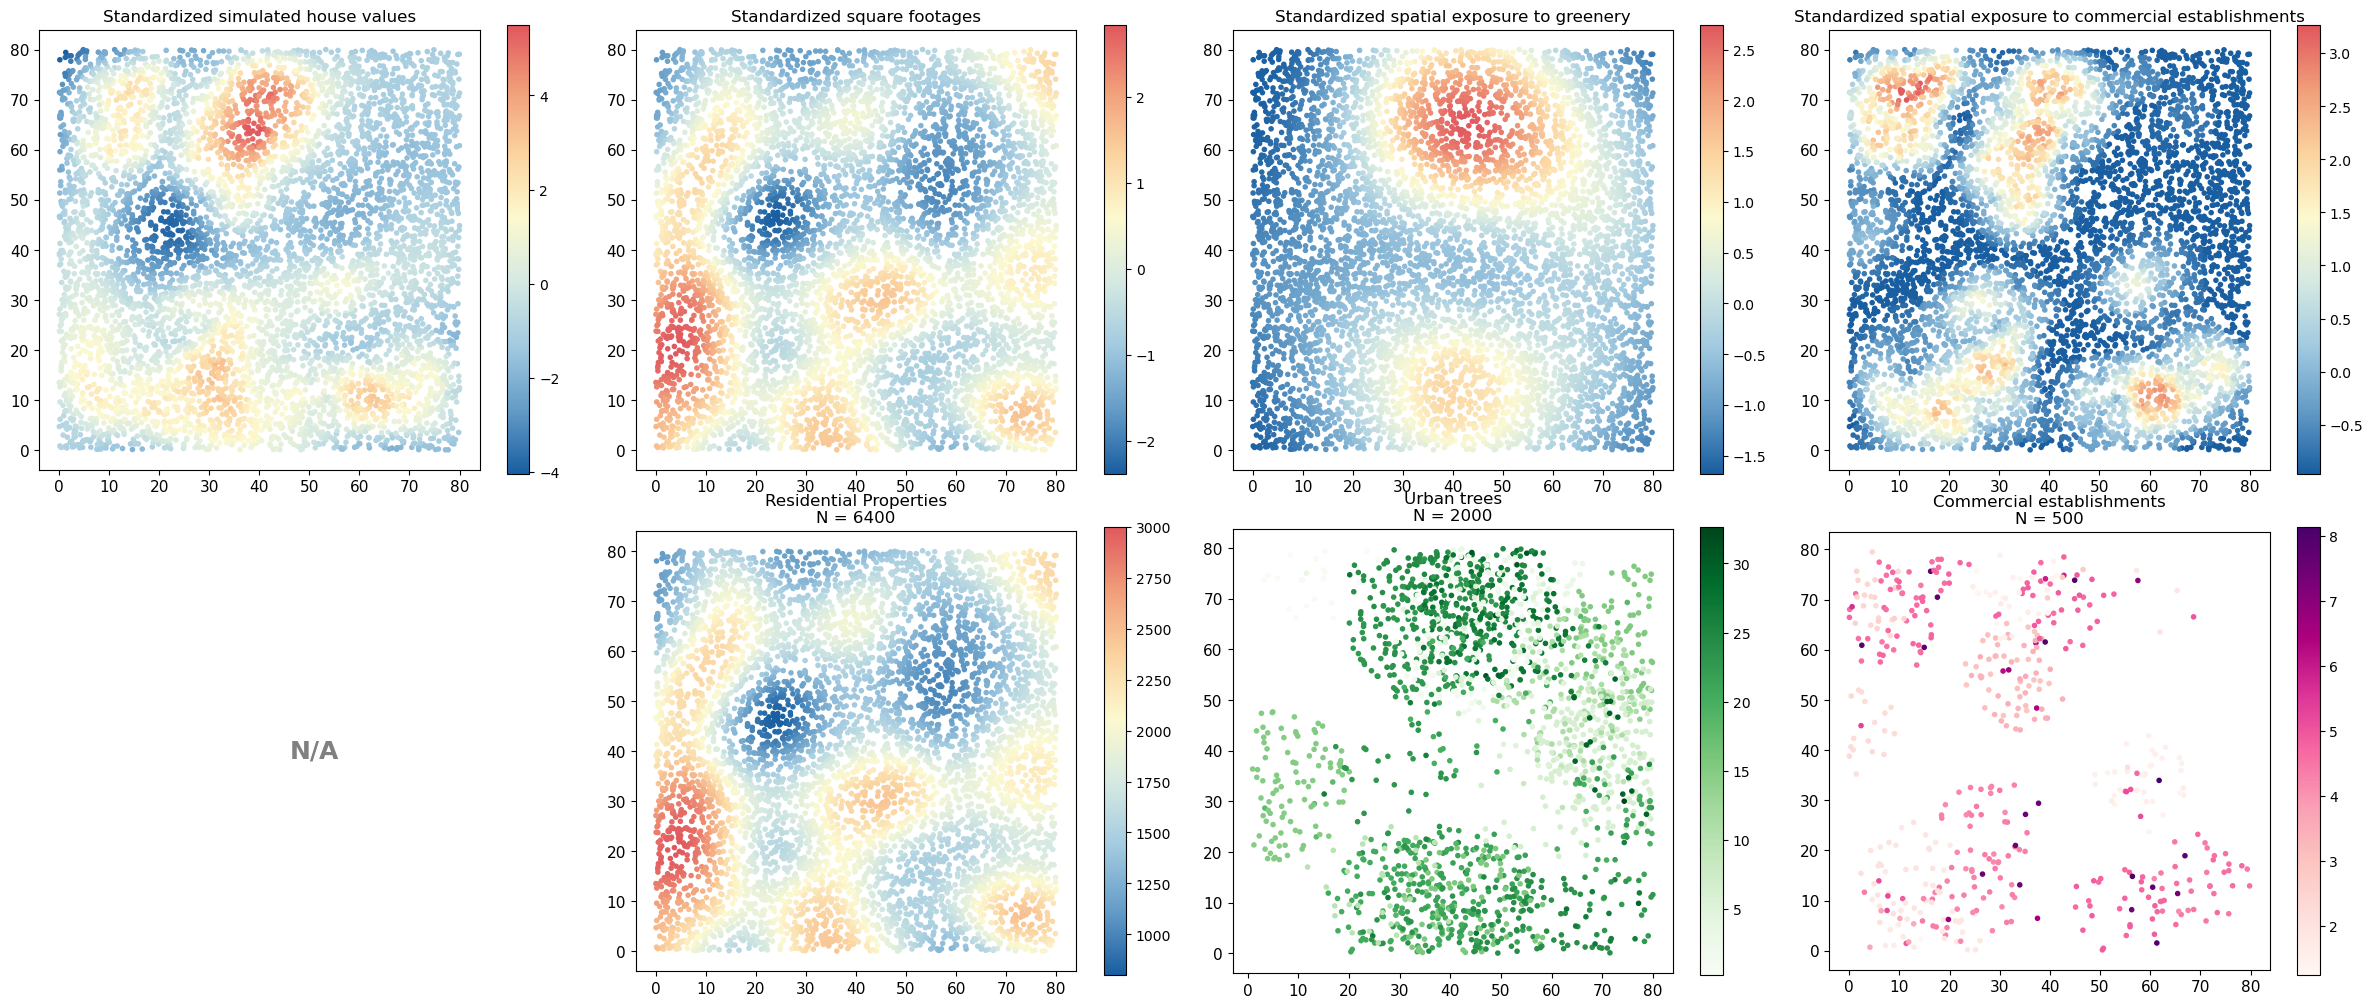

In [43]:
from scipy.stats import zscore
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(24, 10))

# -------- config --------


row1 = [
    dict(df=X1sX2sX3df, x='Lon', y='Lat', c='y',   title='Standardized simulated house values', z=False),
    dict(df=X1sX2sX3df, x='Lon', y='Lat', c='X1',  title='Standardized square footages', z=True),
    dict(df=X1sX2sX3df, x='Lon', y='Lat', c='sX2', title='Standardized spatial exposure to greenery', z=True),
    dict(df=X1sX2sX3df, x='Lon', y='Lat', c='sX3', title='Standardized spatial exposure to commercial establishments', z=True),
]

row2 = [
    None,  # first panel blank
    dict(df=X1sX2sX3df, x='Lon', y='Lat', c='X1',title='Residential Properties', n_label='N = 6400',cbar='House footage (sqft)', cmap='ocean_stage2'),
    dict(df=X2_gdf, x='Lon', y='Lat', c='X2',title='Urban trees', n_label='N = 2000', cbar='Diameter at breast height (cm)', cmap='Greens'),
    dict(df=X3_gdf, x='Lon', y='Lat', c='X3', title='Commercial establishments', n_label='N = 500', cbar='Business tier index', cmap='RdPu'),
]

# -------- row 1 --------
for j, spec in enumerate(row1):
    ax = axes[0, j]
    vals = spec['df'][spec['c']]
    if spec.get('z', False):
        vals = zscore(vals)

    sc = ax.scatter(spec['df'][spec['x']], spec['df'][spec['y']],
                    c=vals, cmap='ocean_stage2', marker='.')
    cb = plt.colorbar(sc, ax=ax)
    #cb.set_label(fontsize=11)
    ax.set_title(spec['title'])
    ax.set_aspect('equal')

# -------- row 2 --------
for j, spec in enumerate(row2):
    ax = axes[1, j]
    if spec is None:
        ax.axis('off')
        ax.text(
            0.5, 0.5, 'N/A',
            transform=ax.transAxes,
            ha='center', va='center',
            fontsize=18, fontweight='bold', color='gray'
        )
        continue

    vals = spec['df'][spec['c']]
    sc = ax.scatter(spec['df'][spec['x']], spec['df'][spec['y']],
                    c=vals, cmap=spec['cmap'], marker='.')
    cb = plt.colorbar(sc, ax=ax)
    #cb.set_label(fontsize=11)
    ax.set_title(f"{spec['title']}\n{spec['n_label']}")
    ax.set_aspect('equal')


for ax in axes.flat:
    ax.tick_params(axis='both', which='major', labelsize=11)

plt.tight_layout()
plt.savefig("dgp_6400.png", dpi = 300)
plt.show()


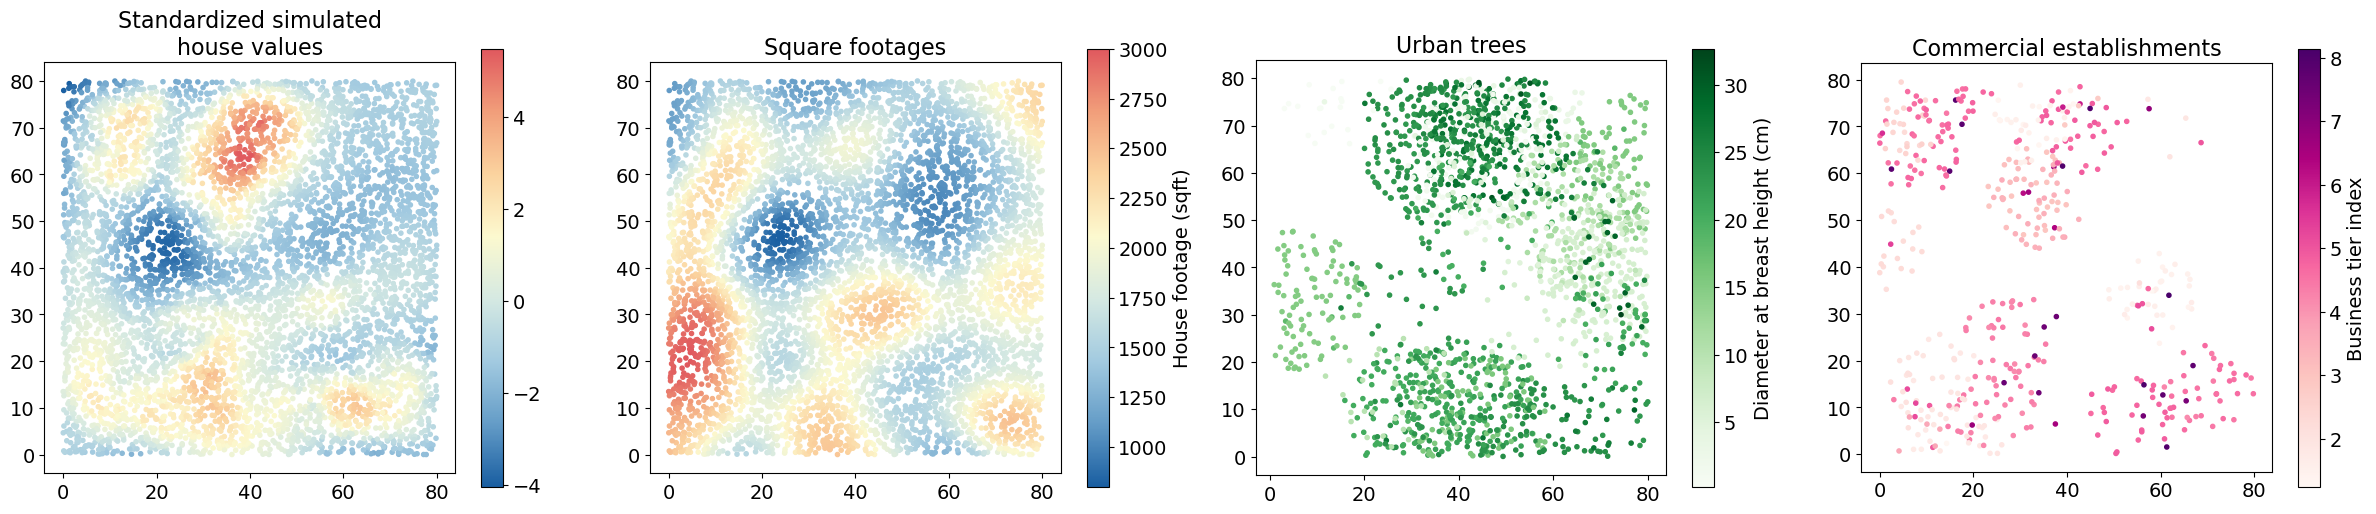

In [75]:
from scipy.stats import zscore
import matplotlib.pyplot as plt

config = [
    dict(df=X1sX2sX3df, x='Lon', y='Lat', c='y',   title='Standardized simulated\nhouse values', z=False, cmap='ocean_stage2'),
    dict(df=X1sX2sX3df, x='Lon', y='Lat', c='X1',  title='Square footages', z=False, cmap='ocean_stage2', cbar='House footage (sqft)'),
    dict(df=X2_gdf,      x='Lon', y='Lat', c='X2',  title='Urban trees', z=False, cmap='Greens', cbar='Diameter at breast height (cm)'),
    dict(df=X3_gdf,      x='Lon', y='Lat', c='X3',  title='Commercial establishments', z=False, cmap='RdPu', cbar='Business tier index'),
]

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.patch.set_facecolor('none')

for j, spec in enumerate(config):
    ax = axes[j]
    ax.set_facecolor('none')
    vals = spec['df'][spec['c']]
    if spec.get('z', False):
        vals = zscore(vals)
    sc = ax.scatter(spec['df'][spec['x']], spec['df'][spec['y']],
                    c=vals, cmap=spec['cmap'], marker='.')
    cb = plt.colorbar(sc, ax=ax)
    if 'cbar' in spec:
        cb.set_label(spec['cbar'], fontsize=14)
    cb.ax.tick_params(labelsize=14)
    ax.set_title(spec['title'], fontsize=16)
    ax.set_aspect('equal')
    ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.savefig("dgp_6400_combined.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

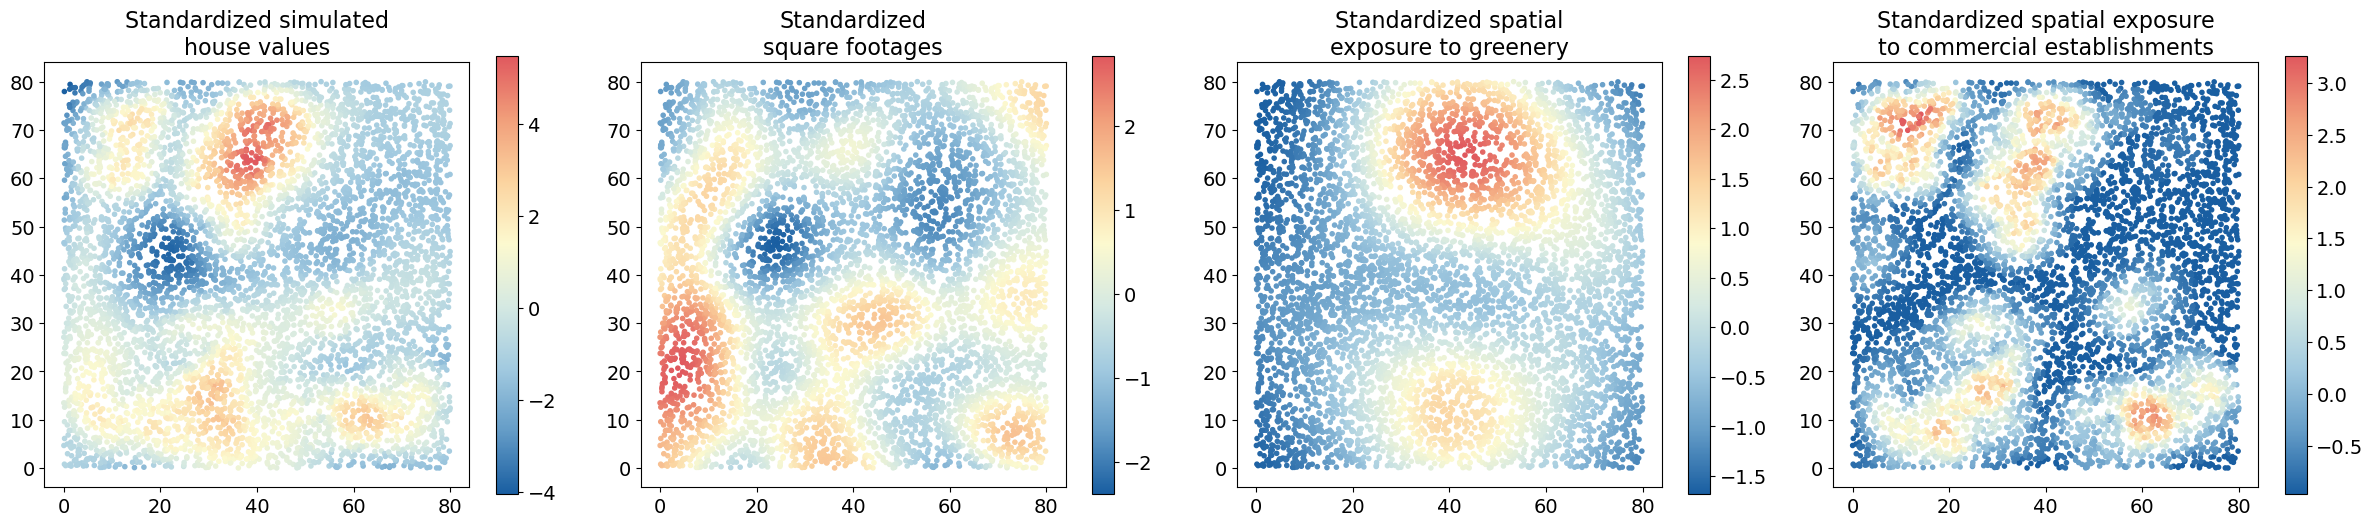

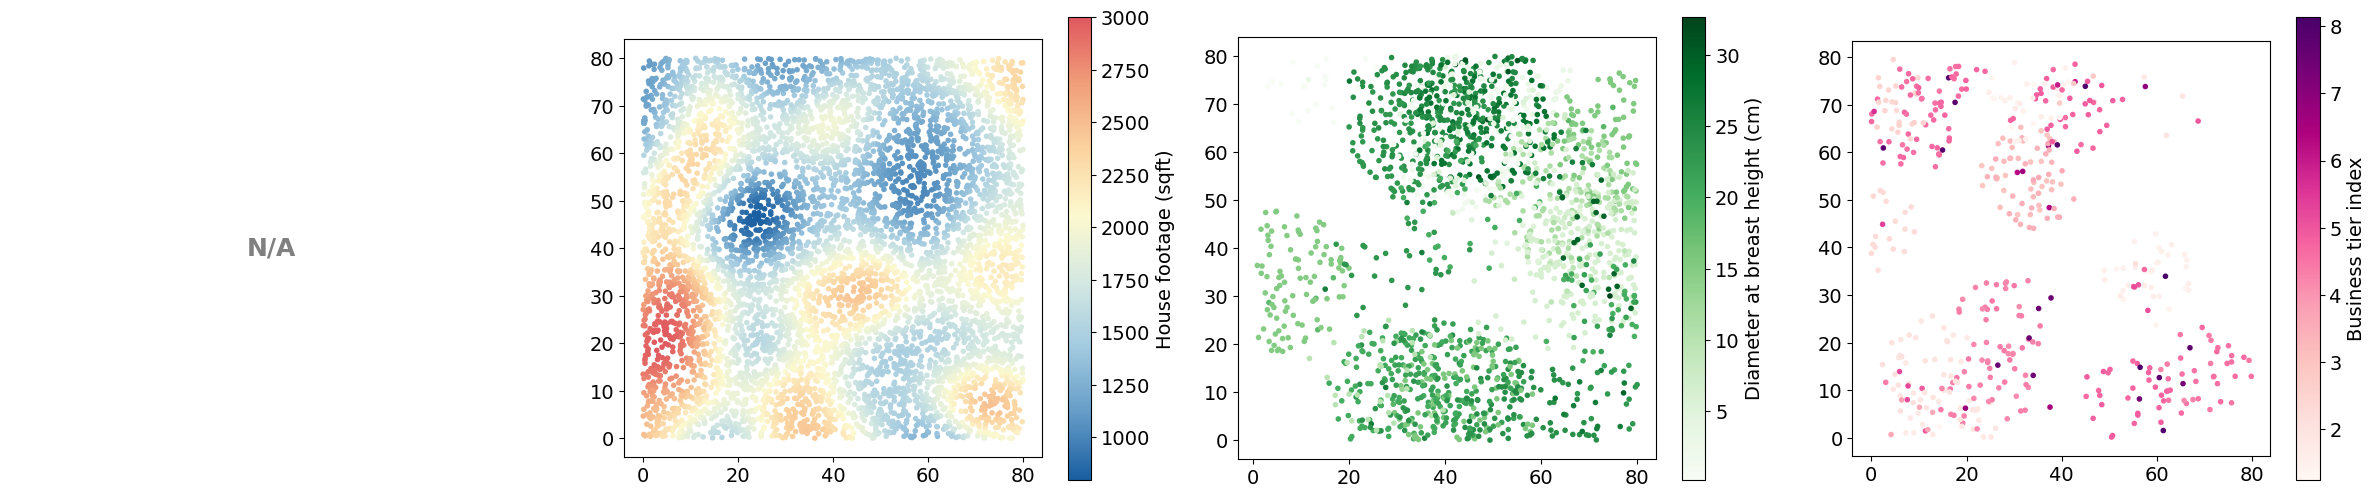

In [48]:
from scipy.stats import zscore
import matplotlib.pyplot as plt

# -------- config --------
row1 = [
    dict(df=X1sX2sX3df, x='Lon', y='Lat', c='y',   title='Standardized simulated\nhouse values', z=False),
    dict(df=X1sX2sX3df, x='Lon', y='Lat', c='X1',  title='Standardized\nsquare footages', z=True),
    dict(df=X1sX2sX3df, x='Lon', y='Lat', c='sX2', title='Standardized spatial\nexposure to greenery', z=True),
    dict(df=X1sX2sX3df, x='Lon', y='Lat', c='sX3', title='Standardized spatial exposure\nto commercial establishments', z=True),
]
row2 = [
    None,
    dict(df=X1sX2sX3df, x='Lon', y='Lat', c='X1', title='Houses', cbar='House footage (sqft)', cmap='ocean_stage2'),
    dict(df=X2_gdf, x='Lon', y='Lat', c='X2', title='Urban trees', cbar='Diameter at breast height (cm)', cmap='Greens'),
    dict(df=X3_gdf, x='Lon', y='Lat', c='X3', title='Commercial establishments', cbar='Business tier index', cmap='RdPu'),
]

# -------- Figure 1: Row 1 --------
fig1, axes1 = plt.subplots(1, 4, figsize=(24, 5))
fig1.patch.set_facecolor('none')
for j, spec in enumerate(row1):
    ax = axes1[j]
    ax.set_facecolor('none')
    vals = spec['df'][spec['c']]
    if spec.get('z', False):
        vals = zscore(vals)
    sc = ax.scatter(spec['df'][spec['x']], spec['df'][spec['y']],
                    c=vals, cmap='ocean_stage2', marker='.')
    cb = plt.colorbar(sc, ax=ax)
    cb.ax.tick_params(labelsize=14)
    ax.set_title(spec['title'], fontsize=16)
    ax.set_aspect('equal')
    ax.tick_params(axis='both', labelsize=14)
plt.tight_layout()
plt.savefig("dgp_6400_row1.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

# -------- Figure 2: Row 2 --------
fig2, axes2 = plt.subplots(1, 4, figsize=(24, 5))
fig2.patch.set_facecolor('none')
for j, spec in enumerate(row2):
    ax = axes2[j]
    ax.set_facecolor('none')
    if spec is None:
        ax.axis('off')
        ax.text(0.5, 0.5, 'N/A', transform=ax.transAxes,
                ha='center', va='center', fontsize=18, fontweight='bold', color='gray')
        continue
    vals = spec['df'][spec['c']]
    sc = ax.scatter(spec['df'][spec['x']], spec['df'][spec['y']],
                    c=vals, cmap=spec['cmap'], marker='.')
    cb = plt.colorbar(sc, ax=ax)
    cb.set_label(spec['cbar'], fontsize=14)
    cb.ax.tick_params(labelsize=14)
    # ax.set_title(spec['title'], fontsize=16)
    ax.set_aspect('equal')
    ax.tick_params(axis='both', labelsize=14)
plt.tight_layout()
plt.savefig("dgp_6400_row2.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

# repeat regression

* y is aggregated to grids
* x1 is aggregated to grids
* x2 is aggregated to grids

In [49]:
import statsmodels.api as sm

grid_names = ['75x75','50x50', '25x25', '20x20', '10x10']
grid_dims = [75, 50, 25, 20, 10]
cell_sizes = [80 / n for n in grid_dims]  

results = [] # y - x_sd_pt 

for i, (grid_dim, cell_size) in enumerate(zip(grid_dims, cell_sizes)):
    
    # Create grids
    grids = create_grids(square, cell_size)
    
    # Aggregate random points
    joined_y = gpd.sjoin(X1sX2sX3df, grids, how="inner", predicate="within")
    agg_y = joined_y.groupby("id", as_index=False).agg(
        avg_y=("y", "mean"), N_y=("y", "size")
    )
    agg_X1 = joined_y.groupby("id", as_index=False).agg(
        avg_X1=("X1", "mean"), N_X1=("X1", "size")
    )

    grids_gdf = grids.merge(agg_y, on="id", how="left")
    grids_gdf = grids_gdf.merge(agg_X1, on="id", how="left")
    
    joined_X2 = gpd.sjoin(X2_gdf, grids, how="inner", predicate="within")

    agg_X2 = joined_X2.groupby("id", as_index=False).agg(
        avg_X2=("X2", "mean"), N_X2=("X2", "size") 
    )
    grids_gdf = grids_gdf.merge(agg_X2, on="id", how="left") 

    joined_X3 = gpd.sjoin(X3_gdf, grids, how="inner", predicate="within")

    agg_X3 = joined_X3.groupby("id", as_index=False).agg(
        avg_X3=("X3", "mean"), N_X3=("X3", "size") 
    )

    grids_gdf = grids_gdf.merge(agg_X3, on="id", how="left") 
    N_valid1 = grids_gdf["N_X2"].isna().sum()
    N_valid2 = grids_gdf["N_X3"].isna().sum()
    grids_gdf[['avg_X2', 'avg_X3']] = grids_gdf[['avg_X2', 'avg_X3']].fillna(0)
    
    # Prepare regression data
    import statsmodels.api as sm

    df = grids_gdf[["avg_X1", "avg_X2", "avg_X3","avg_y"]].copy()
    df = df.dropna(subset=["avg_y"])

    X = df[["avg_X1", "avg_X2", "avg_X3"]].to_numpy()
    y = df["avg_y"].to_numpy()
    
    X_std = (X - X.mean(axis=0)) / X.std(axis=0)
    
    y_std = (y - y.mean()) / y.std()
   
    # Fit model
    model = sm.OLS(y, X_std).fit()
    
    # Store results
    n_zones = len(grids)
    
    results.append({
        'Zone': grid_names[i],
        'N Zones': n_zones,
        'N Obs': len(df),
        'N X2': N_valid1,
        'N X3': N_valid2,
        'b1': f"{model.params[0]:.4f} ({model.conf_int()[0][0]:.4f}, {model.conf_int()[0][1]:.4f})",
        'b2': f"{model.params[1]:.4f} ({model.conf_int()[1][0]:.4f}, {model.conf_int()[1][1]:.4f})",
        'b3': f"{model.params[2]:.4f} ({model.conf_int()[2][0]:.4f}, {model.conf_int()[2][1]:.4f})",
        'R²': model.rsquared,
        'AIC': model.aic
    })

# Create and display results table
results_df = pd.DataFrame(results)


In [50]:
# Round specific columns
results_df_display = results_df.copy()
results_df_display['R²'] = results_df_display['R²'].round(4)
results_df_display['AIC'] = results_df_display['AIC'].round(2)

from IPython.display import display

display(results_df_display)

,Zone,N Zones,N Obs,N X2,N X3,b1,b2,b3,R²,AIC
0,75x75,5625,3805,4135,5168,"0.6394 (0.5970, 0.6819)","0.3783 (0.3358, 0.4208)","0.2915 (0.2491, 0.3338)",0.2567,12977.26
1,50x50,2500,2316,1384,2081,"0.6531 (0.6014, 0.7048)","0.4556 (0.4039, 0.5072)","0.4260 (0.3747, 0.4773)",0.3227,7643.02
2,25x25,625,625,164,357,"0.6078 (0.5195, 0.6962)","0.4329 (0.3446, 0.5212)","0.6978 (0.6098, 0.7858)",0.4554,1916.88
3,20x20,400,400,78,198,"0.5639 (0.4596, 0.6683)","0.4289 (0.3248, 0.5330)","0.7767 (0.6726, 0.8809)",0.5076,1182.78
4,10x10,100,100,10,23,"0.4911 (0.2760, 0.7062)","0.2602 (0.0377, 0.4826)","0.6244 (0.4019, 0.8468)",0.4146,302.15


# repeat regression - downscaling

In [58]:
from gass_iwls3 import GASS_iwls

grid_names = ['75x75', '50x50', '25x25', '20x20', '10x10']
grid_dims = [75, 50, 25, 20, 10]
cell_sizes = [120 / n for n in grid_dims]  
results2 = [] # y - X_sd_pt

from tqdm import tqdm

for i, (grid_dim, cell_size) in enumerate(tqdm(zip(grid_dims, cell_sizes), total=len(grid_dims), desc="Processing grids")):    
# for i, (grid_dim, cell_size) in enumerate(zip(grid_dims, cell_sizes)):
    
    # Create grids
    grids = create_grids(square, cell_size)
    
    # Aggregate random points
    joined_y = gpd.sjoin(X1sX2sX3df, grids, how="inner", predicate="within")
    agg_y = joined_y.groupby("id", as_index=False).agg(
        avg_y=("y", "mean"), N_y=("y", "size")
    )
    agg_X1 = joined_y.groupby("id", as_index=False).agg(
        avg_X1=("X1", "mean"), N_X1=("X1", "size")
    )

    grids_gdf = grids.merge(agg_y, on="id", how="left")
    grids_gdf = grids_gdf.merge(agg_X1, on="id", how="left")
    
    joined_X2 = gpd.sjoin(X2_gdf, grids, how="inner", predicate="within")

    agg_X2 = joined_X2.groupby("id", as_index=False).agg(
        avg_X2=("X2", "mean"), N_X2=("X2", "size") 
    )
    grids_gdf = grids_gdf.merge(agg_X2, on="id", how="left") 

    joined_X3 = gpd.sjoin(X3_gdf, grids, how="inner", predicate="within")

    agg_X3 = joined_X3.groupby("id", as_index=False).agg(
        avg_X3=("X3", "mean"), N_X3=("X3", "size") 
    )

    grids_gdf = grids_gdf.merge(agg_X3, on="id", how="left") 
    grids_gdf[['avg_X2', 'avg_X3']] = grids_gdf[['avg_X2', 'avg_X3']].fillna(0)

    # Make sure points have geometry
    import geopandas as gpd

    points_gdf = gpd.GeoDataFrame(
        X1sX2sX3df,
        geometry=gpd.points_from_xy(X1sX2sX3df['Lon'], X1sX2sX3df['Lat']),
        crs=grids_gdf.crs
    )
    
    # Only keep the columns we need from grids
    # grids_subset = grids_gdf[['geometry', 'avg_X2', 'avg_X3']].copy()
    
    # Spatial join
    # print(points_gdf.columns)
    joined = gpd.sjoin(points_gdf, grids_subset, how='left', predicate='within')
    
    # Fallback for edge cases
    missing_mask = joined['avg_X2'].isna()
    if missing_mask.sum() > 0:
        nearest = gpd.sjoin_nearest(
            points_gdf.loc[missing_mask.index[missing_mask]],
            grids_subset, how='left'
        )
        joined.loc[missing_mask, ['avg_X2', 'avg_X3']] = nearest[['avg_X2', 'avg_X3']].values
    
    # Rename and drop join artifacts
    joined = joined.rename(columns={'avg_X2': 'd_avg_X2', 'avg_X3': 'd_avg_X3'})
    joined = joined.drop(columns=['index_right'])
    
    # Now joined has original point columns + d_avg_X2, d_avg_X3

    import statsmodels.api as sm

    df = joined[["X1", "d_avg_X2", "d_avg_X3", "y"]].copy()
    df = df.dropna(subset=["y"])

    X = df[["X1", "d_avg_X2", "d_avg_X3"]].to_numpy()
    y = df["y"].to_numpy()
    
    X_std = (X - X.mean(axis=0)) / X.std(axis=0)
    y_std = (y - y.mean()) / y.std()
   
    # Fit model
    model = sm.OLS(y, X_std).fit()
    
    # Store results
    n_zones = len(grids)
    
    results2.append({
        'Zone': grid_names[i],
        'N Zones': n_zones,
        'N Obs': len(df),
        'b1': f"{model.params[0]:.4f} ({model.conf_int()[0][0]:.4f}, {model.conf_int()[0][1]:.4f})",
        'b2': f"{model.params[1]:.4f} ({model.conf_int()[1][0]:.4f}, {model.conf_int()[1][1]:.4f})",
        'b3': f"{model.params[2]:.4f} ({model.conf_int()[2][0]:.4f}, {model.conf_int()[2][1]:.4f})",
        'R²': model.rsquared,
        'AIC': model.aic
    })
   
# Create and display results table
results2_df = pd.DataFrame(results2)


Processing grids: 100%|███████████████████████████| 5/5 [00:00<00:00, 23.45it/s]


In [59]:
# Round specific columns
results2_df_display = results2_df.copy()
results2_df_display['R²'] = results2_df_display['R²'].round(4)
results2_df_display['AIC'] = results2_df_display['AIC'].round(2)

from IPython.display import display

display(results2_df_display)

,Zone,N Zones,N Obs,N X2,N X3,b1,b2,b3,R²,AIC
0,75x75,2500,6400,1384,2081,"0.6548 (0.6231, 0.6866)","0.4592 (0.4275, 0.4910)","0.4411 (0.4095, 0.4727)",0.3196,21410.58
1,50x50,1156,6400,440,822,"0.6548 (0.6231, 0.6866)","0.4592 (0.4275, 0.4910)","0.4411 (0.4095, 0.4727)",0.3196,21410.58
2,25x25,289,6400,39,129,"0.6548 (0.6231, 0.6866)","0.4592 (0.4275, 0.4910)","0.4411 (0.4095, 0.4727)",0.3196,21410.58
3,20x20,196,6400,23,72,"0.6548 (0.6231, 0.6866)","0.4592 (0.4275, 0.4910)","0.4411 (0.4095, 0.4727)",0.3196,21410.58
4,10x10,49,6400,2,9,"0.6548 (0.6231, 0.6866)","0.4592 (0.4275, 0.4910)","0.4411 (0.4095, 0.4727)",0.3196,21410.58


In [122]:
from gass_iwls3 import GASS_iwls

grid_names = ['75x75', '50x50', '25x25', '20x20', '10x10']
grid_dims = [75, 50, 25, 20, 10]
cell_sizes = [120 / n for n in grid_dims]  
resultsg3 = [] # y - X_sd_pt
gass_models3=[]

from tqdm import tqdm

for i, (grid_dim, cell_size) in enumerate(tqdm(zip(grid_dims, cell_sizes), total=len(grid_dims), desc="Processing grids")):    
# for i, (grid_dim, cell_size) in enumerate(zip(grid_dims, cell_sizes)):
    
    # Create grids
    grids = create_grids(square, cell_size)
    
    # Aggregate random points
    joined_y = gpd.sjoin(X1sX2sX3df, grids, how="inner", predicate="within")
    agg_y = joined_y.groupby("id", as_index=False).agg(
        avg_y=("y", "mean"), N_y=("y", "size")
    )
    agg_X1 = joined_y.groupby("id", as_index=False).agg(
        avg_X1=("X1", "mean"), N_X1=("X1", "size")
    )

    grids_gdf = grids.merge(agg_y, on="id", how="left")
    grids_gdf = grids_gdf.merge(agg_X1, on="id", how="left")
    
    joined_X2 = gpd.sjoin(X2_gdf, grids, how="inner", predicate="within")

    agg_X2 = joined_X2.groupby("id", as_index=False).agg(
        avg_X2=("X2", "mean"), N_X2=("X2", "size") 
    )
    grids_gdf = grids_gdf.merge(agg_X2, on="id", how="left") 

    joined_X3 = gpd.sjoin(X3_gdf, grids, how="inner", predicate="within")

    agg_X3 = joined_X3.groupby("id", as_index=False).agg(
        avg_X3=("X3", "mean"), N_X3=("X3", "size") 
    )

    grids_gdf = grids_gdf.merge(agg_X3, on="id", how="left") 
    N_valid1 = grids_gdf["N_X2"].isna().sum()
    N_valid2 = grids_gdf["N_X3"].isna().sum()
    # grids_gdf[['avg_X2']] = grids_gdf[['avg_X2']].fillna(0)
    
    # grids_gdf[['avg_X2']] = grids_gdf[['avg_X2']].fillna(0)
    
    # Prepare regression data
    grids_rna_gdf = grids_gdf.dropna(subset=["avg_y"])
    X2_grids = grids_gdf.dropna(subset=["avg_X2"])
    X3_grids = grids_gdf.dropna(subset=["avg_X3"])
    
    grids_rna_gdf['geometry'] = grids_rna_gdf.geometry.centroid
    X2_grids['geometry'] = X2_grids.geometry.centroid
    X3_grids['geometry'] = X3_grids.geometry.centroid
    
    ids_grid_sX2_sd = DistanceSmoothing(data1 = X1sX2sX3df, data2 = X2_grids, attr='avg_X2',
                                        isInverse = True, self_neighboring = False, 
                                        row_standard = False, standard = True)
    ids_grid_sX2_sd.cal2(np.arange(-3, 0, 0.001).round(3))

    ids_grid_sX3_sd = DistanceSmoothing(data1 = X1sX2sX3df, data2 = X3_grids, attr='avg_X3',
                                        isInverse = True, self_neighboring = False, 
                                        row_standard = False, standard = True)
    ids_grid_sX3_sd.cal2(np.arange(-3, 0, 0.001).round(3))
    
    lin_X1_sd = LinearTerm(X1sX2sX3df, 4, standard = True)
    
    y = X1sX2sX3df['y']
    y_sd = (y - np.mean(y))/np.std(y)
    gass_grids = GASS_iwls(y, lin_X1_sd, ids_grid_sX2_sd, ids_grid_sX3_sd, constant = False)

    gass_grids.fit()
    gass_grids.inference()
    gass_grids.calculate_AWCI_scales()
    
    # Store results
    n_zones = len(grids)
    resultsg3.append({
        'Zone': grid_names[i],
        'N Zones': n_zones,
        'N Obs': len(y),
        'N X2': N_valid1,
        'N X3': N_valid2,
        'b1': f"{gass_grids.coefficients[0]:.4f} ({gass_grids.CI_betas[0][0]:.4f}, {gass_grids.CI_betas[0][1]:.4f})",
        'b2': f"{gass_grids.coefficients[1]:.4f} ({gass_grids.CI_betas[1][0]:.4f}, {gass_grids.CI_betas[1][1]:.4f})",
        'b3': f"{gass_grids.coefficients[2]:.4f} ({gass_grids.CI_betas[2][0]:.4f}, {gass_grids.CI_betas[2][1]:.4f})",
        'R²': gass_grids.R_squared,
        'AIC': gass_grids.AIC,
        'sig1': f"{gass_grids.scales[0]:.4f} ({gass_grids.AWCI_scales[0][0]:.4f}, {gass_grids.AWCI_scales[0][1]:.4f})",
        'sig2': f"{gass_grids.scales[1]:.4f} ({gass_grids.AWCI_scales[1][0]:.4f}, {gass_grids.AWCI_scales[1][1]:.4f})"
    })
    gass_models3.append(gass_grids)

# Create and display results table
resultsg3_df = pd.DataFrame(resultsg3)


Processing grids: 100%|██████████████████████████| 5/5 [08:57<00:00, 107.55s/it]


# repeated GASS 1

* y is aggregated to grids
* x1 is aggregated to grids
* x2 is aggregated to grids, then using GASS for smoothing around grids

In [118]:
from gass_iwls3 import GASS_iwls

grid_names = ['75x75', '50x50', '25x25', '20x20', '10x10']
grid_dims = [75, 50, 25, 20, 10]
cell_sizes = [80 / n for n in grid_dims]  
resultsg = [] # y - X_sd_pt
gass_models=[]


from tqdm import tqdm

for i, (grid_dim, cell_size) in enumerate(tqdm(zip(grid_dims, cell_sizes), total=len(grid_dims), desc="Processing grids")):    
# for i, (grid_dim, cell_size) in enumerate(zip(grid_dims, cell_sizes)):
    
    # Create grids
    grids = create_grids(square, cell_size)
    
    # Aggregate random points
    joined_y = gpd.sjoin(X1sX2sX3df, grids, how="inner", predicate="within")
    agg_y = joined_y.groupby("id", as_index=False).agg(
        avg_y=("y", "mean"), N_y=("y", "size")
    )
    agg_X1 = joined_y.groupby("id", as_index=False).agg(
        avg_X1=("X1", "mean"), N_X1=("X1", "size")
    )

    grids_gdf = grids.merge(agg_y, on="id", how="left")
    grids_gdf = grids_gdf.merge(agg_X1, on="id", how="left")
    
    joined_X2 = gpd.sjoin(X2_gdf, grids, how="inner", predicate="within")

    agg_X2 = joined_X2.groupby("id", as_index=False).agg(
        avg_X2=("X2", "mean"), N_X2=("X2", "size") 
    )
    grids_gdf = grids_gdf.merge(agg_X2, on="id", how="left") 

    joined_X3 = gpd.sjoin(X3_gdf, grids, how="inner", predicate="within")

    agg_X3 = joined_X3.groupby("id", as_index=False).agg(
        avg_X3=("X3", "mean"), N_X3=("X3", "size") 
    )

    grids_gdf = grids_gdf.merge(agg_X3, on="id", how="left") 
    N_valid1 = grids_gdf["N_X2"].isna().sum()
    N_valid2 = grids_gdf["N_X3"].isna().sum()
    # grids_gdf[['avg_X2']] = grids_gdf[['avg_X2']].fillna(0)
    
    # Prepare regression data
    grids_rna_gdf = grids_gdf.dropna(subset=["avg_y"])
    X2_grids = grids_gdf.dropna(subset=["avg_X2"])
    X3_grids = grids_gdf.dropna(subset=["avg_X3"])
    
    grids_rna_gdf['geometry'] = grids_rna_gdf.geometry.centroid
    X2_grids['geometry'] = X2_grids.geometry.centroid
    X3_grids['geometry'] = X3_grids.geometry.centroid
    
    ids_grid_sX2_sd = DistanceSmoothing(data1 = grids_rna_gdf, data2 = X2_grids, attr='avg_X2',
                                        isInverse = True, self_neighboring = False, 
                                        row_standard = False, standard = True)
    ids_grid_sX2_sd.cal2(np.arange(-3, 0, 0.001).round(3))

    ids_grid_sX3_sd = DistanceSmoothing(data1 = grids_rna_gdf, data2 = X3_grids, attr='avg_X3',
                                        isInverse = True, self_neighboring = False, 
                                        row_standard = False, standard = True)
    ids_grid_sX3_sd.cal2(np.arange(-3, 0, 0.001).round(3))
    
    lin_grid_X1_sd = LinearTerm(grids_rna_gdf, 4, standard = True)
    
    grids_y = grids_rna_gdf['avg_y']
    grids_y_sd = (grids_y - np.mean(grids_y))/np.std(grids_y)
    gass_grids = GASS_iwls(grids_y, lin_grid_X1_sd, ids_grid_sX2_sd, ids_grid_sX3_sd, constant = False)
    
    gass_grids.fit()
    gass_grids.inference()
    gass_grids.calculate_AWCI_scales()
    
    # Store results
    n_zones = len(grids)
    resultsg.append({
        'Zone': grid_names[i],
        'N Zones': n_zones,
        'N Obs': len(grids_rna_gdf),
        'N X2': N_valid1,
        'N X3': N_valid2,
        'b1': f"{gass_grids.coefficients[0]:.4f} ({gass_grids.CI_betas[0][0]:.4f}, {gass_grids.CI_betas[0][1]:.4f})",
        'b2': f"{gass_grids.coefficients[1]:.4f} ({gass_grids.CI_betas[1][0]:.4f}, {gass_grids.CI_betas[1][1]:.4f})",
        'b3': f"{gass_grids.coefficients[2]:.4f} ({gass_grids.CI_betas[2][0]:.4f}, {gass_grids.CI_betas[2][1]:.4f})",
        'R²': gass_grids.R_squared,
        'AIC': gass_grids.AIC,
        'sig1': f"{gass_grids.scales[0]:.4f} ({gass_grids.AWCI_scales[0][0]:.4f}, {gass_grids.AWCI_scales[0][1]:.4f})",
        'sig2': f"{gass_grids.scales[1]:.4f} ({gass_grids.AWCI_scales[1][0]:.4f}, {gass_grids.AWCI_scales[1][1]:.4f})"
    })
    gass_models.append(resultsg)

# Create and display results table
resultsg_df = pd.DataFrame(resultsg)


Processing grids: 100%|███████████████████████████| 5/5 [02:00<00:00, 24.14s/it]


In [119]:
# Round specific columns
resultsg_df_display = resultsg_df.copy()
resultsg_df_display['R²'] = resultsg_df_display['R²'].round(4)
resultsg_df_display['AIC'] = resultsg_df_display['AIC'].round(2)

from IPython.display import display
display(resultsg_df_display)

,Zone,N Zones,N Obs,N X2,N X3,b1,b2,b3,R²,AIC,sig1,sig2
0,75x75,5625,3805,4135,5168,"0.8551 (0.8404, 0.8698)","0.9095 (0.8932, 0.9259)","0.9238 (0.9085, 0.9391)",0.9040,5191.13,"-1.3840 (-1.4100, -1.3540)","-1.7270 (-1.7500, -1.7070)"
1,50x50,2500,2316,1384,2081,"0.8115 (0.7924, 0.8306)","0.8594 (0.8380, 0.8808)","0.9503 (0.9301, 0.9704)",0.8968,3287.72,"-1.5340 (-1.5800, -1.4940)","-2.0500 (-2.1000, -2.0100)"
2,25x25,625,625,164,357,"0.6371 (0.5807, 0.6935)","0.6110 (0.5479, 0.6742)","0.8958 (0.8347, 0.9570)",0.7470,1440.74,"-1.9260 (-2.1700, -1.7160)","-3.0000 (-3.0000, -2.7500)"
3,20x20,400,400,78,198,"0.5537 (0.4785, 0.6288)","0.4718 (0.3866, 0.5570)","0.8920 (0.8078, 0.9763)",0.7010,986.21,"-2.7230 (-3.0000, -2.2630)","-3.0000 (-3.0000, -2.8100)"
4,10x10,100,100,10,23,"0.4861 (0.2859, 0.6863)","-0.2511 (-0.4617, -0.0406)","0.7351 (0.5264, 0.9437)",0.4467,299.53,"-0.0220 (-3.0000, -0.0120)","-3.0000 (-3.0000, -2.2300)"


# repeated GASS 2

* y is aggregated to grids
* x1 is aggregated to grids
* x2 is points, using GASS for smoothing around grids

In [120]:
from gass_iwls3 import GASS_iwls

grid_names = ['75x75', '50x50', '25x25', '20x20', '10x10']
grid_dims = [75, 50, 25, 20, 10]
cell_sizes = [120 / n for n in grid_dims]  
resultsg2 = [] # y - X_sd_pt
gass_models2=[]

from tqdm import tqdm

for i, (grid_dim, cell_size) in enumerate(tqdm(zip(grid_dims, cell_sizes), total=len(grid_dims), desc="Processing grids")):    
# for i, (grid_dim, cell_size) in enumerate(zip(grid_dims, cell_sizes)):
    
    # Create grids
    grids = create_grids(square, cell_size)
    
    # Aggregate random points
    joined_y = gpd.sjoin(X1sX2sX3df, grids, how="inner", predicate="within")
    agg_y = joined_y.groupby("id", as_index=False).agg(
        avg_y=("y", "mean"), N_y=("y", "size")
    )
    agg_X1 = joined_y.groupby("id", as_index=False).agg(
        avg_X1=("X1", "mean"), N_X1=("X1", "size")
    )

    grids_gdf = grids.merge(agg_y, on="id", how="left")
    grids_gdf = grids_gdf.merge(agg_X1, on="id", how="left")
    
    # Prepare regression data
    grids_rna_gdf = grids_gdf.dropna(subset=["avg_y"])
    grids_rna_gdf['geometry'] = grids_rna_gdf.geometry.centroid
    
    ids_grid_sX2_sd = DistanceSmoothing(data1 = grids_rna_gdf, data2 = X2_gdf, attr='X2',
                                        isInverse = True, self_neighboring = False, 
                                        row_standard = False, standard = True)
    ids_grid_sX2_sd.cal2(np.arange(-3, 0, 0.001).round(3))

    ids_grid_sX3_sd = DistanceSmoothing(data1 = grids_rna_gdf, data2 = X3_gdf, attr='X3',
                                        isInverse = True, self_neighboring = False, 
                                        row_standard = False, standard = True)
    ids_grid_sX3_sd.cal2(np.arange(-3, 0, 0.001).round(3))
    
    lin_grid_X1_sd = LinearTerm(grids_rna_gdf, 4, standard = True)
    
    grids_y = grids_rna_gdf['avg_y']
    grids_y_sd = (grids_y - np.mean(grids_y))/np.std(grids_y)
    gass_grids = GASS_iwls(grids_y, lin_grid_X1_sd, ids_grid_sX2_sd, ids_grid_sX3_sd, constant = False)

    gass_grids.fit()
    gass_grids.inference()
    gass_grids.calculate_AWCI_scales()
    
    # Store results
    n_zones = len(grids)
    resultsg2.append({
        'Zone': grid_names[i],
        'N Zones': n_zones,
        'N Obs': len(grids_rna_gdf),
        'N X2': len(X2_gdf),
        'N X3': len(X3_gdf),
        'b1': f"{gass_grids.coefficients[0]:.4f} ({gass_grids.CI_betas[0][0]:.4f}, {gass_grids.CI_betas[0][1]:.4f})",
        'b2': f"{gass_grids.coefficients[1]:.4f} ({gass_grids.CI_betas[1][0]:.4f}, {gass_grids.CI_betas[1][1]:.4f})",
        'b3': f"{gass_grids.coefficients[2]:.4f} ({gass_grids.CI_betas[2][0]:.4f}, {gass_grids.CI_betas[2][1]:.4f})",
        'R²': gass_grids.R_squared,
        'AIC': gass_grids.AIC,
        'sig1': f"{gass_grids.scales[0]:.4f} ({gass_grids.AWCI_scales[0][0]:.4f}, {gass_grids.AWCI_scales[0][1]:.4f})",
        'sig2': f"{gass_grids.scales[1]:.4f} ({gass_grids.AWCI_scales[1][0]:.4f}, {gass_grids.AWCI_scales[1][1]:.4f})"
    })
    gass_models2.append(resultsg2)

# Create and display results table
resultsg2_df = pd.DataFrame(resultsg2)


Processing grids: 100%|███████████████████████████| 5/5 [01:19<00:00, 15.81s/it]


In [121]:
# Round specific columns
resultsg2_df_display = resultsg2_df.copy()
resultsg2_df_display['R²'] = resultsg2_df_display['R²'].round(4)
resultsg2_df_display['AIC'] = resultsg2_df_display['AIC'].round(2)

from IPython.display import display
display(resultsg2_df_display)

,Zone,N Zones,N Obs,N X2,N X3,b1,b2,b3,R²,AIC,sig1,sig2
0,75x75,2500,2316,2000,500,"0.9023 (0.8742, 0.9303)","0.8723 (0.8407, 0.9038)","0.8001 (0.7710, 0.8293)",0.7884,4951.60,"-1.0140 (-1.0300, -0.9940)","-1.0290 (-1.0400, -1.0090)"
1,50x50,1156,1145,2000,500,"0.9021 (0.8655, 0.9388)","0.8805 (0.8395, 0.9215)","0.8213 (0.7834, 0.8592)",0.8207,2248.61,"-1.0360 (-1.0700, -1.0060)","-1.1210 (-1.1500, -1.1010)"
2,25x25,289,289,2000,500,"0.8942 (0.8280, 0.9604)","0.8968 (0.8248, 0.9689)","0.8309 (0.7638, 0.8981)",0.8492,506.24,"-1.1340 (-1.2000, -1.0640)","-1.1660 (-1.2100, -1.1160)"
3,20x20,196,196,2000,500,"0.8524 (0.7634, 0.9413)","0.8648 (0.7685, 0.9611)","0.7476 (0.6571, 0.8380)",0.8130,379.55,"-1.2280 (-1.3300, -1.1180)","-0.9970 (-1.0700, -0.9270)"
4,10x10,49,49,2000,500,"0.8662 (0.7294, 1.0030)","0.9366 (0.8036, 1.0697)","0.7701 (0.6508, 0.8895)",0.8960,58.60,"-1.1550 (-1.3000, -0.9850)","-1.2790 (-1.4300, -1.1390)"


# repeated GASS 3

* y is points
* x1 is points
* x2 is aggregated to grids, then using GASS for smoothing around points

In [122]:
from gass_iwls3 import GASS_iwls

grid_names = ['75x75', '50x50', '25x25', '20x20', '10x10']
grid_dims = [75, 50, 25, 20, 10]
cell_sizes = [120 / n for n in grid_dims]  
resultsg3 = [] # y - X_sd_pt
gass_models3=[]

from tqdm import tqdm

for i, (grid_dim, cell_size) in enumerate(tqdm(zip(grid_dims, cell_sizes), total=len(grid_dims), desc="Processing grids")):    
# for i, (grid_dim, cell_size) in enumerate(zip(grid_dims, cell_sizes)):
    
    # Create grids
    grids = create_grids(square, cell_size)
    
    # Aggregate random points
    joined_y = gpd.sjoin(X1sX2sX3df, grids, how="inner", predicate="within")
    agg_y = joined_y.groupby("id", as_index=False).agg(
        avg_y=("y", "mean"), N_y=("y", "size")
    )
    agg_X1 = joined_y.groupby("id", as_index=False).agg(
        avg_X1=("X1", "mean"), N_X1=("X1", "size")
    )

    grids_gdf = grids.merge(agg_y, on="id", how="left")
    grids_gdf = grids_gdf.merge(agg_X1, on="id", how="left")
    
    joined_X2 = gpd.sjoin(X2_gdf, grids, how="inner", predicate="within")

    agg_X2 = joined_X2.groupby("id", as_index=False).agg(
        avg_X2=("X2", "mean"), N_X2=("X2", "size") 
    )
    grids_gdf = grids_gdf.merge(agg_X2, on="id", how="left") 

    joined_X3 = gpd.sjoin(X3_gdf, grids, how="inner", predicate="within")

    agg_X3 = joined_X3.groupby("id", as_index=False).agg(
        avg_X3=("X3", "mean"), N_X3=("X3", "size") 
    )

    grids_gdf = grids_gdf.merge(agg_X3, on="id", how="left") 
    N_valid1 = grids_gdf["N_X2"].isna().sum()
    N_valid2 = grids_gdf["N_X3"].isna().sum()
    # grids_gdf[['avg_X2']] = grids_gdf[['avg_X2']].fillna(0)
    
    # grids_gdf[['avg_X2']] = grids_gdf[['avg_X2']].fillna(0)
    
    # Prepare regression data
    grids_rna_gdf = grids_gdf.dropna(subset=["avg_y"])
    X2_grids = grids_gdf.dropna(subset=["avg_X2"])
    X3_grids = grids_gdf.dropna(subset=["avg_X3"])
    
    grids_rna_gdf['geometry'] = grids_rna_gdf.geometry.centroid
    X2_grids['geometry'] = X2_grids.geometry.centroid
    X3_grids['geometry'] = X3_grids.geometry.centroid
    
    ids_grid_sX2_sd = DistanceSmoothing(data1 = X1sX2sX3df, data2 = X2_grids, attr='avg_X2',
                                        isInverse = True, self_neighboring = False, 
                                        row_standard = False, standard = True)
    ids_grid_sX2_sd.cal2(np.arange(-3, 0, 0.001).round(3))

    ids_grid_sX3_sd = DistanceSmoothing(data1 = X1sX2sX3df, data2 = X3_grids, attr='avg_X3',
                                        isInverse = True, self_neighboring = False, 
                                        row_standard = False, standard = True)
    ids_grid_sX3_sd.cal2(np.arange(-3, 0, 0.001).round(3))
    
    lin_X1_sd = LinearTerm(X1sX2sX3df, 4, standard = True)
    
    y = X1sX2sX3df['y']
    y_sd = (y - np.mean(y))/np.std(y)
    gass_grids = GASS_iwls(y, lin_X1_sd, ids_grid_sX2_sd, ids_grid_sX3_sd, constant = False)

    gass_grids.fit()
    gass_grids.inference()
    gass_grids.calculate_AWCI_scales()
    
    # Store results
    n_zones = len(grids)
    resultsg3.append({
        'Zone': grid_names[i],
        'N Zones': n_zones,
        'N Obs': len(y),
        'N X2': N_valid1,
        'N X3': N_valid2,
        'b1': f"{gass_grids.coefficients[0]:.4f} ({gass_grids.CI_betas[0][0]:.4f}, {gass_grids.CI_betas[0][1]:.4f})",
        'b2': f"{gass_grids.coefficients[1]:.4f} ({gass_grids.CI_betas[1][0]:.4f}, {gass_grids.CI_betas[1][1]:.4f})",
        'b3': f"{gass_grids.coefficients[2]:.4f} ({gass_grids.CI_betas[2][0]:.4f}, {gass_grids.CI_betas[2][1]:.4f})",
        'R²': gass_grids.R_squared,
        'AIC': gass_grids.AIC,
        'sig1': f"{gass_grids.scales[0]:.4f} ({gass_grids.AWCI_scales[0][0]:.4f}, {gass_grids.AWCI_scales[0][1]:.4f})",
        'sig2': f"{gass_grids.scales[1]:.4f} ({gass_grids.AWCI_scales[1][0]:.4f}, {gass_grids.AWCI_scales[1][1]:.4f})"
    })
    gass_models3.append(gass_grids)

# Create and display results table
resultsg3_df = pd.DataFrame(resultsg3)


Processing grids: 100%|██████████████████████████| 5/5 [08:57<00:00, 107.55s/it]


In [123]:
# Round specific columns
resultsg3_df_display = resultsg3_df.copy()
resultsg3_df_display['R²'] = resultsg3_df_display['R²'].round(4)
resultsg3_df_display['AIC'] = resultsg3_df_display['AIC'].round(2)

from IPython.display import display
display(resultsg3_df_display)

,Zone,N Zones,N Obs,N X2,N X3,b1,b2,b3,R²,AIC,sig1,sig2
0,75x75,2500,6400,1384,2081,"0.8435 (0.8232, 0.8637)","0.7394 (0.7166, 0.7622)","0.8293 (0.8081, 0.8504)",0.7046,16074.79,"-0.9410 (-0.9500, -0.9310)","-1.0420 (-1.0500, -1.0320)"
1,50x50,1156,6400,440,822,"0.7616 (0.7381, 0.7851)","0.5149 (0.4877, 0.5421)","0.7838 (0.7581, 0.8095)",0.5889,18190.11,"-0.9240 (-0.9400, -0.9040)","-0.9390 (-0.9500, -0.9290)"
2,25x25,289,6400,39,129,"0.5921 (0.5651, 0.6191)","0.0965 (0.0627, 0.1303)","0.7844 (0.7518, 0.8171)",0.4365,20207.60,"-0.9210 (-1.0200, -0.8010)","-0.9440 (-0.9600, -0.9240)"
3,20x20,196,6400,23,72,"0.5938 (0.5662, 0.6215)","-0.2461 (-0.2793, -0.2128)","0.7706 (0.7373, 0.8039)",0.3595,21027.58,"-1.4780 (-1.6000, -1.3780)","-0.7990 (-0.8100, -0.7790)"
4,10x10,49,6400,2,9,"0.5597 (0.5277, 0.5917)","-0.2696 (-0.3263, -0.2129)","0.6996 (0.6455, 0.7537)",0.2616,21937.43,"-0.0100 (-0.0700, -0.0200)","-0.5930 (-0.6300, -0.5530)"


# GASS 4

In [130]:
resultsg4 = []
lin_X1_sd = LinearTerm(X1sX2sX3df, 4, standard = True)
ids_sX2_sd = DistanceSmoothing(data1 = X1sX2sX3df, data2 = X2_gdf, attr='X2',
                                        isInverse = True, self_neighboring = False, 
                                        row_standard = False, standard = True)
ids_sX2_sd.cal2(np.arange(-3, 0, 0.001).round(3))

ids_sX3_sd = DistanceSmoothing(data1 = X1sX2sX3df, data2 = X3_gdf, attr='X3',
                               isInverse = True, self_neighboring = False, 
                               row_standard = False, standard = True)
ids_sX3_sd.cal2(np.arange(-3, 0, 0.001).round(3))

y = X1sX2sX3df['y']
gass_pts = GASS_iwls(y, lin_X1_sd, ids_sX2_sd, ids_sX3_sd, constant = False)
gass_pts.fit()
gass_pts.inference()
gass_pts.calculate_AWCI_scales()

# Store results
resultsg4.append({
    'N Obs': len(y),
    'N X2': len(X2_gdf),
    'N X3': len(X3_gdf),
    'b1': f"{gass_pts.coefficients[0]:.4f} ({gass_pts.CI_betas[0][0]:.4f}, {gass_pts.CI_betas[0][1]:.4f})",
    'b2': f"{gass_pts.coefficients[1]:.4f} ({gass_pts.CI_betas[1][0]:.4f}, {gass_pts.CI_betas[1][1]:.4f})",
    'b3': f"{gass_pts.coefficients[2]:.4f} ({gass_pts.CI_betas[2][0]:.4f}, {gass_pts.CI_betas[2][1]:.4f})",
    'R²': gass_pts.R_squared,
    'AIC': gass_pts.AIC,
    'sig1': f"{gass_pts.scales[0]:.4f} ({gass_pts.AWCI_scales[0][0]:.4f}, {gass_pts.AWCI_scales[0][1]:.4f})",
    'sig2': f"{gass_pts.scales[1]:.4f} ({gass_pts.AWCI_scales[1][0]:.4f}, {gass_pts.AWCI_scales[1][1]:.4f})"
})

In [131]:
# Round specific columns
# Create and display results table
resultsg4_df = pd.DataFrame(resultsg4)

resultsg4_df_display = resultsg4_df.copy()
resultsg4_df_display['R²'] = resultsg4_df_display['R²'].round(4)
resultsg4_df_display['AIC'] = resultsg4_df_display['AIC'].round(2)

from IPython.display import display
display(resultsg4_df_display)

,N Obs,N X2,N X3,b1,b2,b3,R²,AIC,sig1,sig2
0,6400,2000,500,"0.9062 (0.8893, 0.9231)","0.9016 (0.8827, 0.9206)","0.8157 (0.7981, 0.8334)",0.7938,13773.9,"-1.0840 (-1.1000, -1.0740)","-1.0100 (-1.0200, -1.0000)"


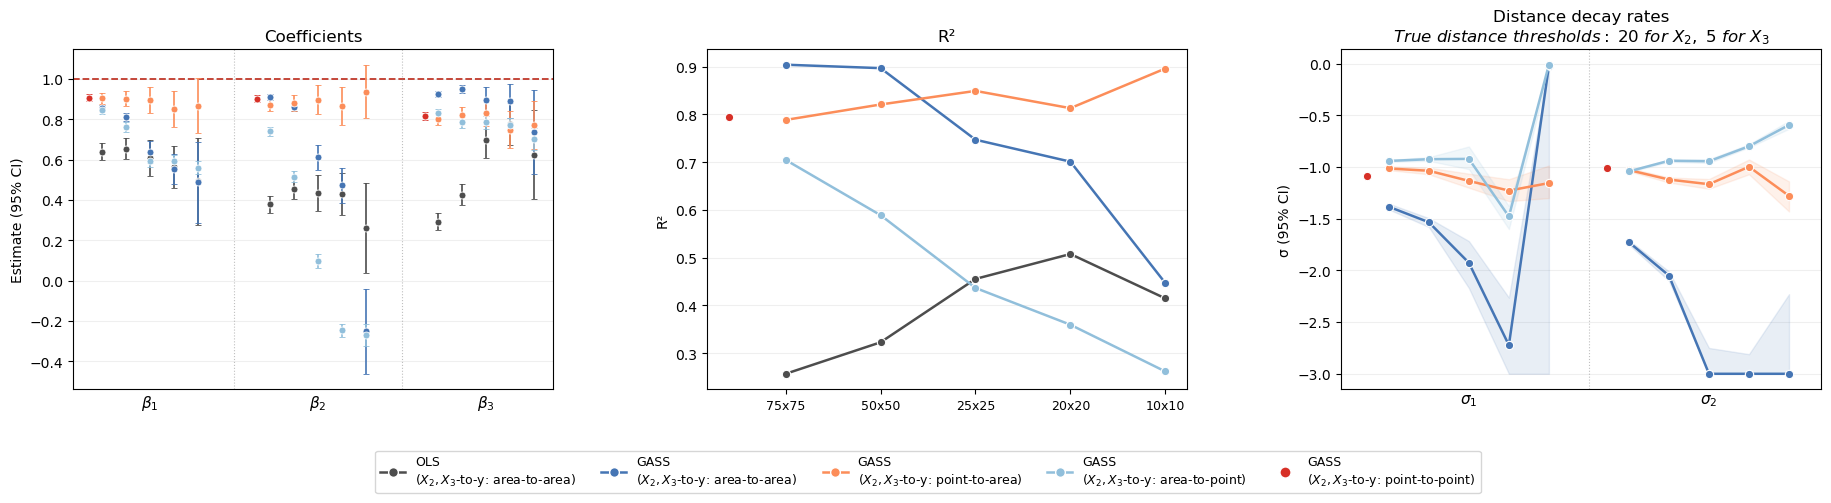

In [257]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

def parse_est_ci_safe(s):
    if pd.isna(s):
        return np.nan, np.nan, np.nan
    m = re.match(r'([\-\d.]+)\s*\(([\-\d.]+),\s*([\-\d.]+)\)', str(s))
    if not m:
        return np.nan, np.nan, np.nan
    return float(m.group(1)), float(m.group(2)), float(m.group(3))

zones = ['75x75', '50x50', '25x25', '20x20', '10x10']
n = len(zones)
x = np.arange(n)

coef_keys = ['b1', 'b2', 'b3']
sigma_keys = ['sig1', 'sig2']

# Elegant palette
COL_OLS  = '#4D4D4D'  # charcoal
COL_A2A  = '#4575B4'  # dark blue
COL_P2A  = '#fc8d59'  # orange
COL_A2P  = '#91BFDB'  # light blue
COL_P2P  = '#d73027'  # red (reference)

def extract_data(df, zones, coef_keys, sigma_keys):
    dfx = df.set_index('Zone').reindex(zones)
    out = {'R2': pd.to_numeric(dfx['R²'], errors='coerce').to_numpy()}

    for k in coef_keys:
        if k in dfx.columns:
            vals = dfx[k].apply(parse_est_ci_safe).tolist()
            out[k] = np.array([t[0] for t in vals], dtype=float)
            out[f'{k}_lo'] = np.array([t[1] for t in vals], dtype=float)
            out[f'{k}_hi'] = np.array([t[2] for t in vals], dtype=float)

    for k in sigma_keys:
        if k in dfx.columns:
            vals = dfx[k].apply(parse_est_ci_safe).tolist()
            out[k] = np.array([t[0] for t in vals], dtype=float)
            out[f'{k}_lo'] = np.array([t[1] for t in vals], dtype=float)
            out[f'{k}_hi'] = np.array([t[2] for t in vals], dtype=float)

    return out

def extract_single_row(df, coef_keys, sigma_keys):
    row = df.iloc[0]
    out = {'R2': float(pd.to_numeric(row.get('R²', np.nan), errors='coerce'))}
    for k in coef_keys:
        if k in df.columns:
            e, lo, hi = parse_est_ci_safe(row[k])
            out[k], out[f'{k}_lo'], out[f'{k}_hi'] = e, lo, hi
    for k in sigma_keys:
        if k in df.columns:
            e, lo, hi = parse_est_ci_safe(row[k])
            out[k], out[f'{k}_lo'], out[f'{k}_hi'] = e, lo, hi
    return out

# multi-scale
d_ols   = extract_data(results_df,   zones, coef_keys, sigma_keys)
d_gass1 = extract_data(resultsg_df,  zones, coef_keys, sigma_keys)
d_gass2 = extract_data(resultsg2_df, zones, coef_keys, sigma_keys)
d_gass3 = extract_data(resultsg3_df, zones, coef_keys, sigma_keys)

# single-row point-to-point
d_gass4 = extract_single_row(resultsg4_df, coef_keys, sigma_keys)

scenarios = [
    ('OLS\n($X_{2}, X_{3}$-to-y: area-to-area)',   d_ols,   COL_OLS, 'o'),
    ('GASS\n($X_{2}, X_{3}$-to-y: area-to-area)',  d_gass1, COL_A2A, 'o'),
    ('GASS\n($X_{2}, X_{3}$-to-y: point-to-area)', d_gass2, COL_P2A, 'o'),
    ('GASS\n($X_{2}, X_{3}$-to-y: area-to-point)', d_gass3, COL_A2P, 'o'),
]


ref_label = 'GASS\n($X_{2}, X_{3}$-to-y: point-to-point)'
ref_col = COL_P2P
ref_mkr = 'o'  # not star

fig, (ax_b, ax_r, ax_s) = plt.subplots(
    1, 3, figsize=(19, 5),
    gridspec_kw={'wspace': 0.32, 'left': 0.05, 'right': 0.97, 'top': 0.88, 'bottom': 0.20}
)

n_scen = len(scenarios)
# offsets = np.linspace(-0.14, 0.14, n_scen)
offsets = np.zeros(n_scen)

# ---------- Panel 1: Coefficients ----------
within_step = 1.0          # spacing between scales inside each beta
inter_block_gap = 3.0      # spacing between beta blocks (increase this)

block_width = (n - 1) * within_step
starts = [i * (block_width + inter_block_gap) for i in range(len(coef_keys))]
x_blocks = [s + np.arange(n) * within_step for s in starts]

for i_s, (name, d, col, mkr) in enumerate(scenarios):
    off = offsets[i_s]
    for block_x, bk in zip(x_blocks, coef_keys):
        if bk not in d:
            continue
        est = d[bk]; lo = d[f'{bk}_lo']; hi = d[f'{bk}_hi']
        valid = np.isfinite(est) & np.isfinite(lo) & np.isfinite(hi)
        if not np.any(valid):
            continue
        yerr = np.vstack([est - lo, hi - est])[:, valid]
        ax_b.errorbar((block_x + off)[valid], est[valid], yerr=yerr, fmt=mkr, color=col,
                      markersize=5, markeredgecolor='white', markeredgewidth=0.6,
                      capsize=2, capthick=1.2, linewidth=1.2, elinewidth=1.2,
                      label=name if bk == coef_keys[0] else None, zorder=4)

# point-to-point references at "scale 0" for each beta block
for i, bk in enumerate(coef_keys):
    if bk in d_gass4 and np.isfinite(d_gass4[bk]):
        x_ref = x_blocks[i][0] - 0.55
        est = d_gass4[bk]
        lo = d_gass4[f'{bk}_lo']
        hi = d_gass4[f'{bk}_hi']
        yerr = np.array([[est - lo], [hi - est]])
        ax_b.errorbar([x_ref], [est], yerr=yerr, fmt=ref_mkr, color=ref_col,
                      markersize=5, markeredgecolor='white', markeredgewidth=0.6,
                      capsize=2, capthick=1.2, linewidth=1.2, elinewidth=1.2,
                      label=ref_label if i == 0 else None, zorder=4)

ax_b.axhline(1.0, color='#c0392b', lw=1.3, ls='--')
ax_b.set_xticks([])
for i in range(len(coef_keys)):
    mid = (x_blocks[i][0] + x_blocks[i][-1]) / 2
    ax_b.text(mid, -0.01, fr'$\beta_{{{i+1}}}$', ha='center', fontsize=11, fontweight='bold',
              transform=ax_b.get_xaxis_transform(), va='top')
    if i < len(coef_keys) - 1:
        sep = (x_blocks[i][-1] + x_blocks[i+1][0]) / 2
        ax_b.axvline(sep, color='grey', lw=0.8, ls=':', alpha=0.5)

# keep references inside each block area
left_margin = x_blocks[0][0] - 1.2
right_margin = x_blocks[-1][-1] + 0.8
ax_b.set_xlim(left_margin, right_margin)

ax_b.set_ylabel('Estimate (95% CI)')
ax_b.set_title('Coefficients')
ax_b.grid(axis='y', alpha=0.2)

# ---------- Panel 2: R² ----------
for i_s, (name, d, col, mkr) in enumerate(scenarios):
    r2 = d['R2']
    valid = np.isfinite(r2)
    if np.any(valid):
        ax_r.plot((x + offsets[i_s])[valid], r2[valid], color=col, marker=mkr,
                  markersize=6, linewidth=1.8, markeredgecolor='white',
                  markeredgewidth=0.8, label=name, zorder=4)

# point-to-point reference at scale 0 (left)
if np.isfinite(d_gass4.get('R2', np.nan)):
    x_ref_r = x[0] - 0.6
    ax_r.plot([x_ref_r], [d_gass4['R2']], color=ref_col, marker=ref_mkr,
              markersize=6, linewidth=0, markeredgecolor='white',
              markeredgewidth=0.8, label=ref_label, zorder=4)

ax_r.set_xticks(x)
ax_r.set_xticklabels(zones, fontsize=9, rotation=0, ha='center')  # horizontal labels
ax_r.set_ylabel('R²')
ax_r.set_title('R²')
ax_r.grid(axis='y', alpha=0.2)

# ---------- Panel 3: Sigma ----------
sigma_gap = n + 1
x_s1 = np.arange(n)
x_s2 = np.arange(n) + sigma_gap
sigma_blocks = [x_s1, x_s2]

for i_s, (name, d, col, mkr) in enumerate(scenarios):
    off = offsets[i_s]
    for block_x, sk in zip(sigma_blocks, sigma_keys):
        if sk not in d:
            continue
        est = d[sk]; lo = d[f'{sk}_lo']; hi = d[f'{sk}_hi']
        valid = np.isfinite(est) & np.isfinite(lo) & np.isfinite(hi)
        if not np.any(valid):
            continue
        xs = (block_x + off)[valid]
        ax_s.fill_between(xs, lo[valid], hi[valid], color=col, alpha=0.12, zorder=2)
        ax_s.plot(xs, est[valid], color=col, marker=mkr, markersize=6, linewidth=1.8,
                  markeredgecolor='white', markeredgewidth=0.8, zorder=4)

# point-to-point references at scale 0 for each sigma block
for j, sk in enumerate(sigma_keys):
    if sk in d_gass4 and np.isfinite(d_gass4[sk]):
        x_ref_s = sigma_blocks[j][0] - 0.55
        est = d_gass4[sk]
        lo = d_gass4[f'{sk}_lo']
        hi = d_gass4[f'{sk}_hi']
        yerr = np.array([[est - lo], [hi - est]])
        ax_s.errorbar([x_ref_s], [est], yerr=yerr, fmt=ref_mkr, color=ref_col,
                      markersize=6, markeredgecolor='white', markeredgewidth=0.8,
                      capsize=3, capthick=1.2, linewidth=1.8, elinewidth=1.4, zorder=4)

ax_s.set_xticks([])
mid_s1 = (x_s1[0] + x_s1[-1]) / 2
mid_s2 = (x_s2[0] + x_s2[-1]) / 2
ax_s.text(mid_s1, -0.01, r'$\sigma_1$', ha='center', fontsize=11, fontweight='bold',
          transform=ax_s.get_xaxis_transform(), va='top')
ax_s.text(mid_s2, -0.01, r'$\sigma_2$', ha='center', fontsize=11, fontweight='bold',
          transform=ax_s.get_xaxis_transform(), va='top')
ax_s.axvline((x_s1[-1] + x_s2[0]) / 2, color='grey', lw=0.8, ls=':', alpha=0.5)

ax_s.set_xlim(sigma_blocks[0][0] - 1.2, sigma_blocks[-1][-1] + 0.8)

ax_s.set_ylabel('σ (95% CI)')
# ax_s.set_title('σ')
ax_s.set_title('Distance decay rates\n' + r'$\it{True\ distance\ thresholds:}\ 20\ for\ X_2,\ 5\ for\ X_3$', fontsize=12)

ax_s.grid(axis='y', alpha=0.2)

# ---------- Legend below ----------
handles = [plt.Line2D([0], [0], color=col, marker=mkr, markersize=7,
                      linewidth=1.8, markeredgecolor='white', label=name)
           for name, _, col, mkr in scenarios]
handles.append(
    plt.Line2D([0], [0], color=ref_col, marker=ref_mkr, markersize=8,
               linewidth=0, markeredgecolor='white', label=ref_label)
)

fig.legend(handles=handles, loc='lower center', ncol=5, fontsize=9,
           frameon=True, fancybox=True, bbox_to_anchor=(0.5, -0.02))

plt.savefig("res_6400.png", dpi = 300)
plt.show()

# repeat viz

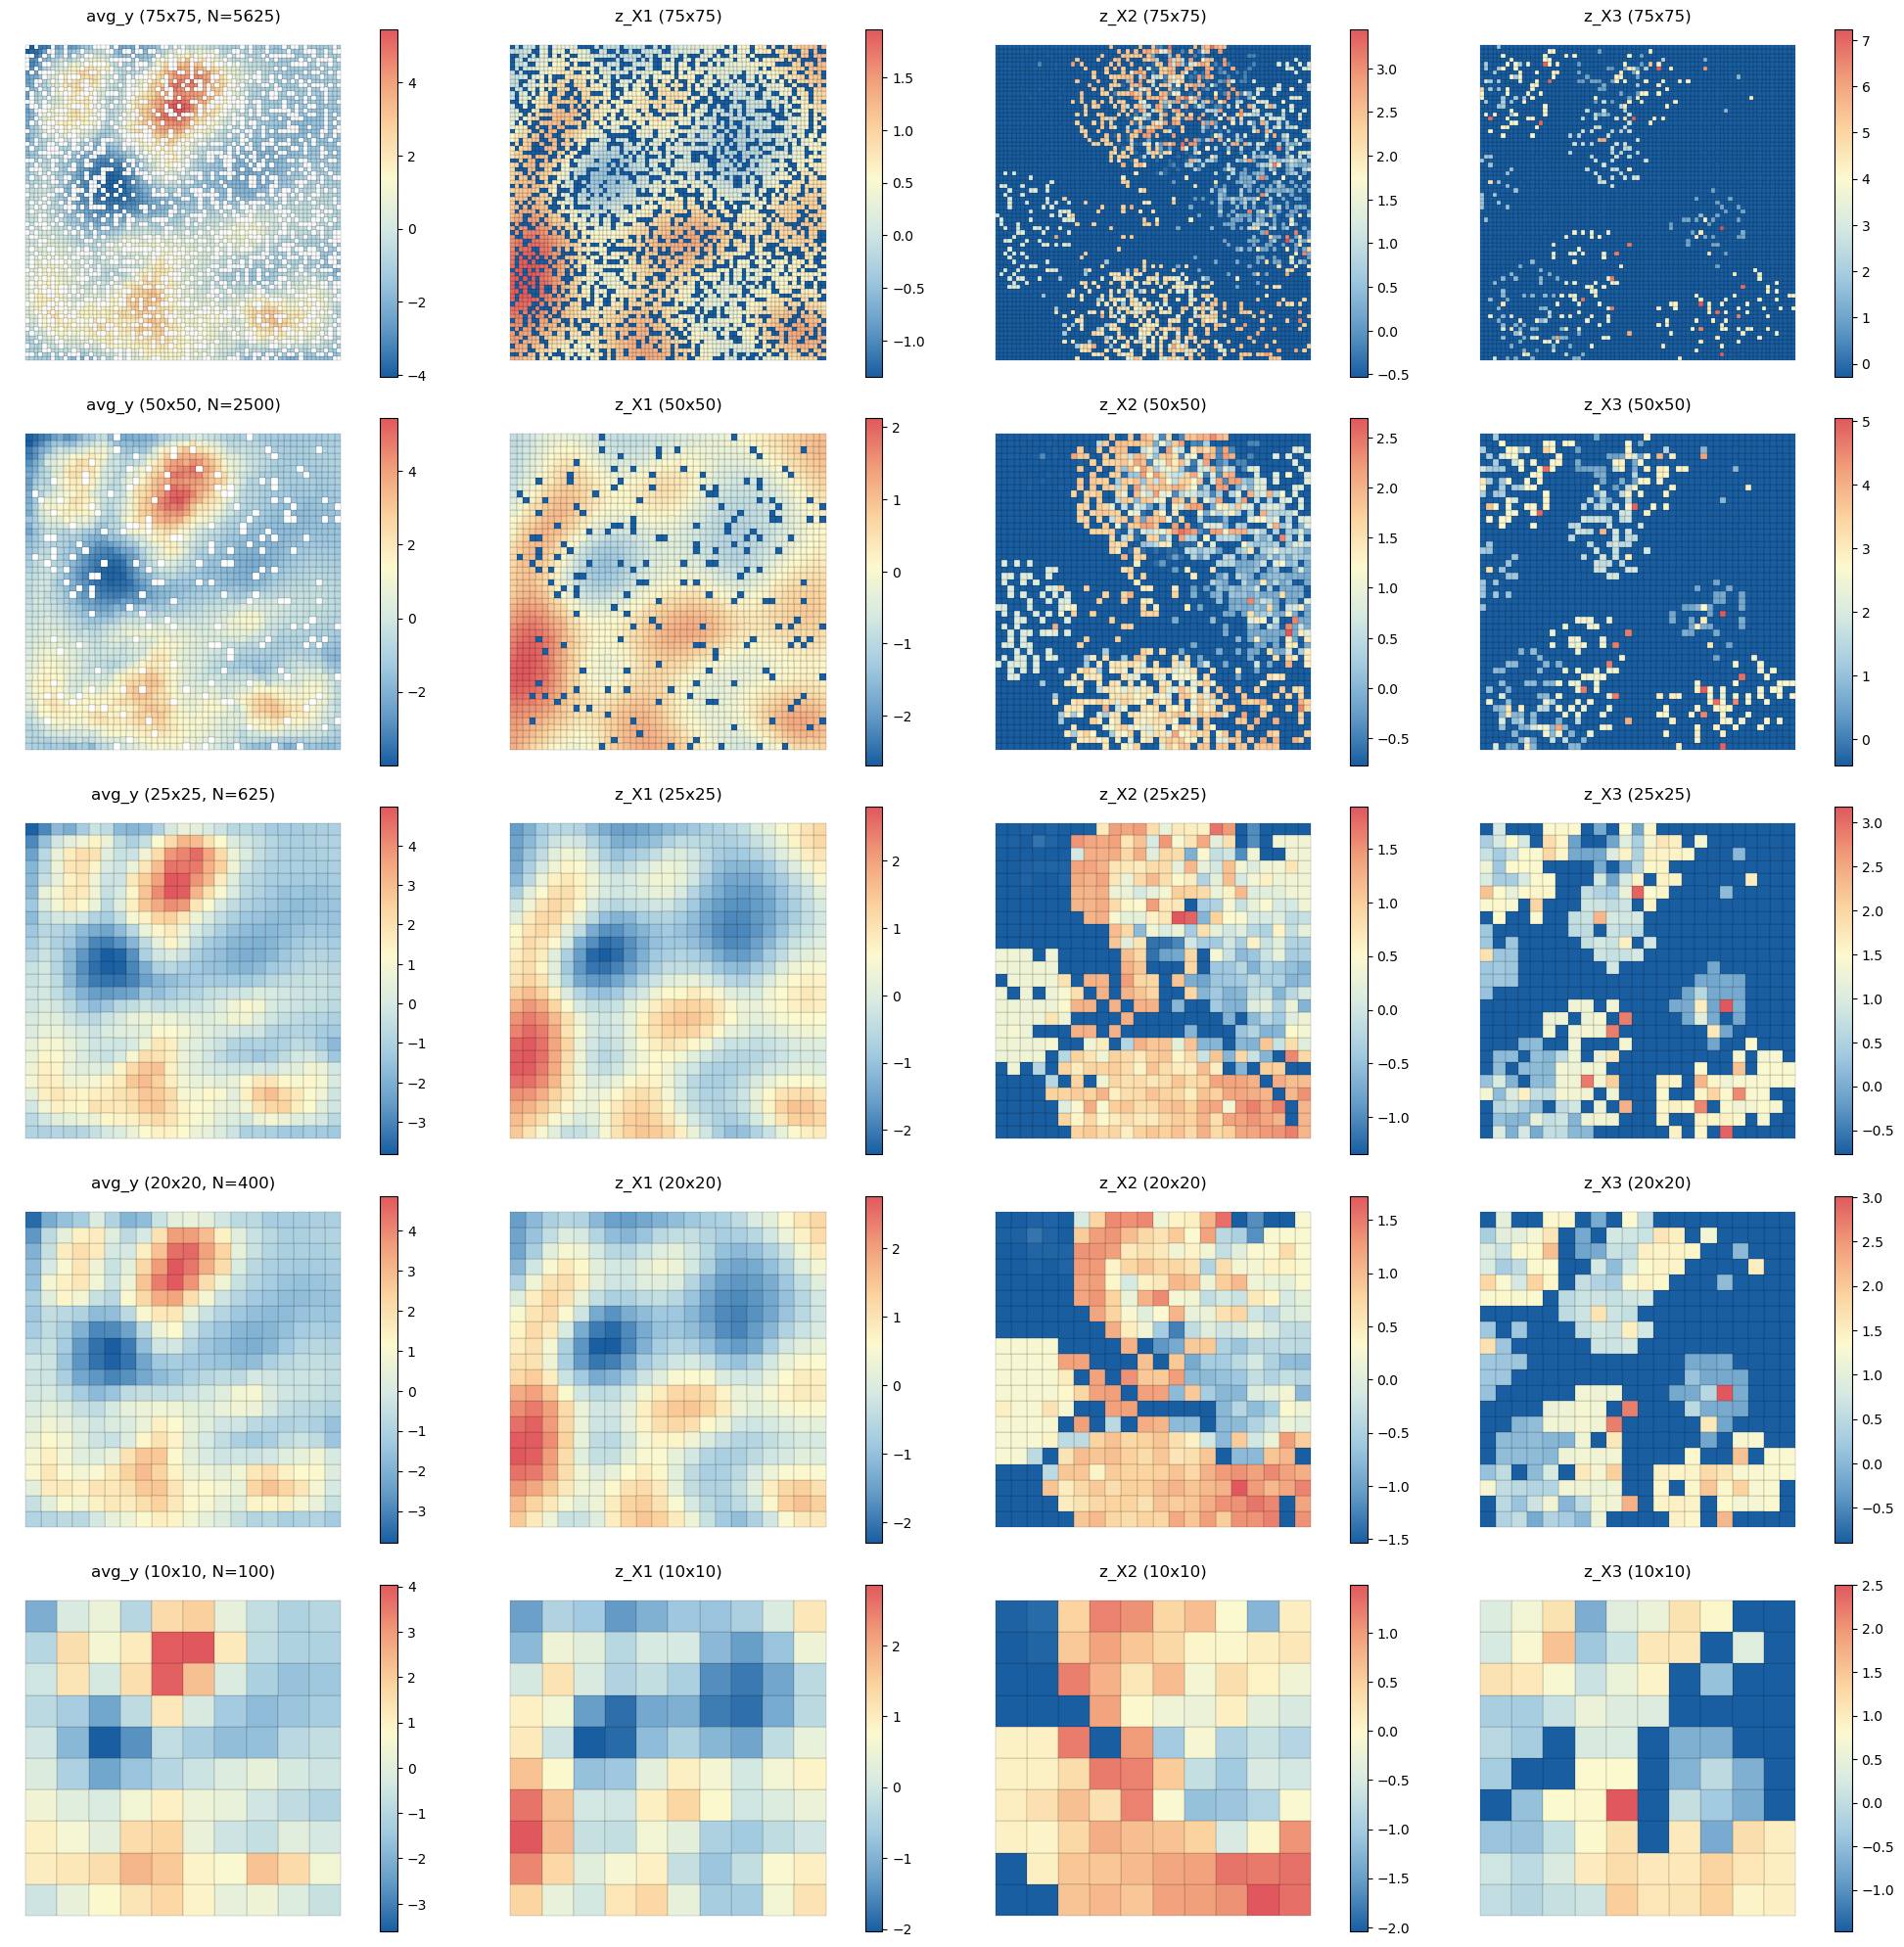

In [71]:
grid_dims = [75, 50, 25, 20, 10]
cell_sizes = [80 / n for n in grid_dims]

# order per row: avg_y, z_X1, z_X2, z_X3
fig, axes = plt.subplots(len(cell_sizes), 4, figsize=(20, 4 * len(cell_sizes)))

for i, (grid_dim, cell_size) in enumerate(zip(grid_dims, cell_sizes)):

    grids = create_grids(square, cell_size)

    # from point table (y, X1)
    joined = gpd.sjoin(X1sX2sX3df, grids, how="inner", predicate="within")
    agg = joined.groupby("id", as_index=False).agg(
        avg_y=("y", "mean"),
        avg_X1=("X1", "mean"),
        N=("y", "size")
    )

    grids_gdf = grids.merge(agg, on="id", how="left")

    # X2 from X2_gdf
    joined_X2 = gpd.sjoin(X2_gdf, grids, how="inner", predicate="within")
    agg_X2 = joined_X2.groupby("id", as_index=False).agg(
        avg_X2=("X2", "mean"),
        N_X2=("X2", "size")
    )
    grids_gdf = grids_gdf.merge(agg_X2, on="id", how="left")
    
    # X3 from X3_gdf
    joined_X3 = gpd.sjoin(X3_gdf, grids, how="inner", predicate="within")
    agg_X3 = joined_X3.groupby("id", as_index=False).agg(
        avg_X3=("X3", "mean"),
        N_X3=("X3", "size")
    )
    grids_gdf = grids_gdf.merge(agg_X3, on="id", how="left")
    grids_gdf[['avg_X1', 'avg_X2', 'avg_X3']] = grids_gdf[['avg_X1', 'avg_X2', 'avg_X3']].fillna(0)

    # standardize
    z_X1  = (grids_gdf["avg_X1"]  - np.nanmean(grids_gdf["avg_X1"]))  / np.nanstd(grids_gdf["avg_X1"])
    z_X2  = (grids_gdf["avg_X2"]  - np.nanmean(grids_gdf["avg_X2"]))  / np.nanstd(grids_gdf["avg_X2"])
    z_X3  = (grids_gdf["avg_X3"]  - np.nanmean(grids_gdf["avg_X3"]))  / np.nanstd(grids_gdf["avg_X3"])

    tmp = grids_gdf.assign(
        z_X1=z_X1, z_X2=z_X2, z_X3=z_X3
    )

    cols_titles = [
        ("avg_y",  f"avg_y ({grid_dim}x{grid_dim}, N={len(grids)})"),
        ("z_X1",   f"z_X1 ({grid_dim}x{grid_dim})"),
        ("z_X2",   f"z_X2 ({grid_dim}x{grid_dim})"),
        ("z_X3",   f"z_X3 ({grid_dim}x{grid_dim})")
    ]

    for j, (col, title) in enumerate(cols_titles):
        tmp.plot(
            column=col,
            cmap="ocean_stage2",
            legend=True,
            edgecolor="k",
            linewidth=0.1,
            missing_kwds={"color": "white", "label": "No data"},
            ax=axes[i, j]
        )
        axes[i, j].set_title(title)
        axes[i, j].set_axis_off()

plt.tight_layout()
plt.savefig("agg_data_6400.png", dpi = 600)
plt.show()

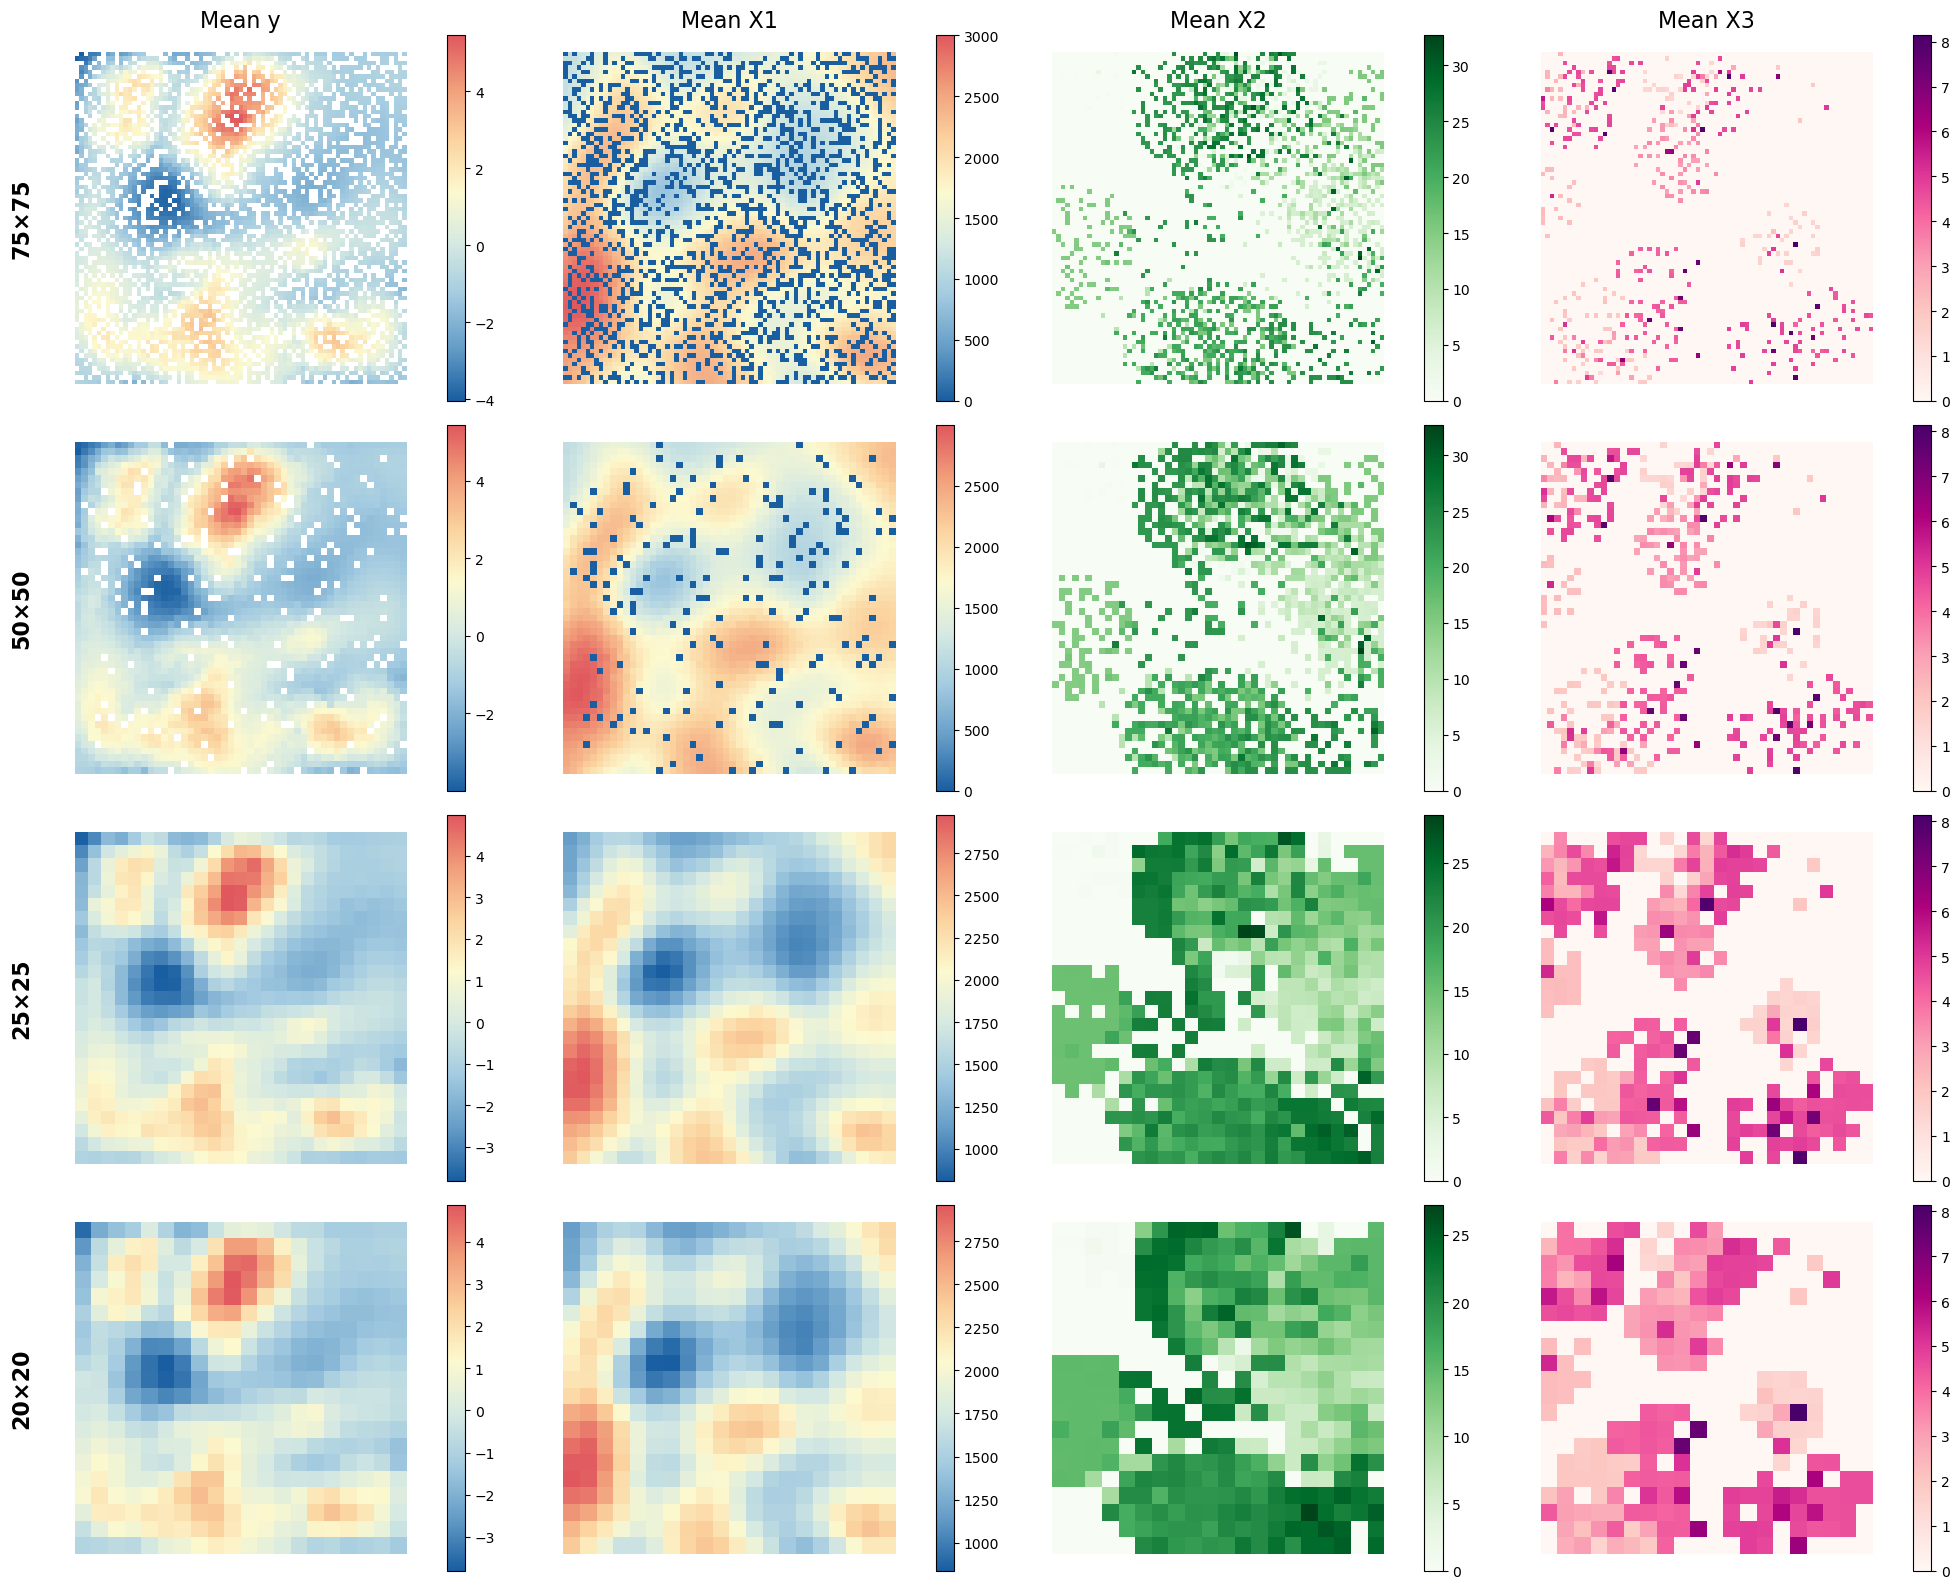

In [73]:
grid_dims = [75, 50, 25, 20]
cell_sizes = [80 / n for n in grid_dims]

fig, axes = plt.subplots(len(grid_dims), 4, figsize=(20, 4 * len(grid_dims)))
fig.patch.set_facecolor('none')

for i, (grid_dim, cell_size) in enumerate(zip(grid_dims, cell_sizes)):
    grids = create_grids(square, cell_size)
    joined = gpd.sjoin(X1sX2sX3df, grids, how="inner", predicate="within")
    agg = joined.groupby("id", as_index=False).agg(
        avg_y=("y", "mean"),
        avg_X1=("X1", "mean"),
        N=("y", "size")
    )
    grids_gdf = grids.merge(agg, on="id", how="left")

    joined_X2 = gpd.sjoin(X2_gdf, grids, how="inner", predicate="within")
    agg_X2 = joined_X2.groupby("id", as_index=False).agg(
        avg_X2=("X2", "mean"),
        N_X2=("X2", "size")
    )
    grids_gdf = grids_gdf.merge(agg_X2, on="id", how="left")

    joined_X3 = gpd.sjoin(X3_gdf, grids, how="inner", predicate="within")
    agg_X3 = joined_X3.groupby("id", as_index=False).agg(
        avg_X3=("X3", "mean"),
        N_X3=("X3", "size")
    )
    grids_gdf = grids_gdf.merge(agg_X3, on="id", how="left")
    grids_gdf[['avg_X1', 'avg_X2', 'avg_X3']] = grids_gdf[['avg_X1', 'avg_X2', 'avg_X3']].fillna(0)

    grids_gdf['z_y'] = (grids_gdf['avg_y'] - np.nanmean(grids_gdf['avg_y'])) / np.nanstd(grids_gdf['avg_y'])

    cols_cmaps = [
        ("avg_y",     "ocean_stage2"),
        ("avg_X1",  "ocean_stage2"),
        ("avg_X2",  "Greens"),
        ("avg_X3",  "RdPu"),
    ]
    for j, (col, cmap) in enumerate(cols_cmaps):
        ax = axes[i, j]
        ax.set_facecolor('none')
        grids_gdf.plot(
            column=col,
            cmap=cmap,
            legend=True,
            edgecolor="none",
            missing_kwds={"color": "white", "label": "No data"},
            ax=ax
        )
        ax.set_axis_off()

    axes[i, 0].text(-0.1, 0.5, f'{grid_dim}×{grid_dim}',
                    transform=axes[i, 0].transAxes, fontsize=16, fontweight='bold',
                    ha='center', va='center', rotation=90)

titles = ['Mean y', 'Mean X1', 'Mean X2', 'Mean X3']
for j, title in enumerate(titles):
    axes[0, j].set_title(title, fontsize=16)

plt.tight_layout()
plt.savefig("agg_data_6400.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

# p2p

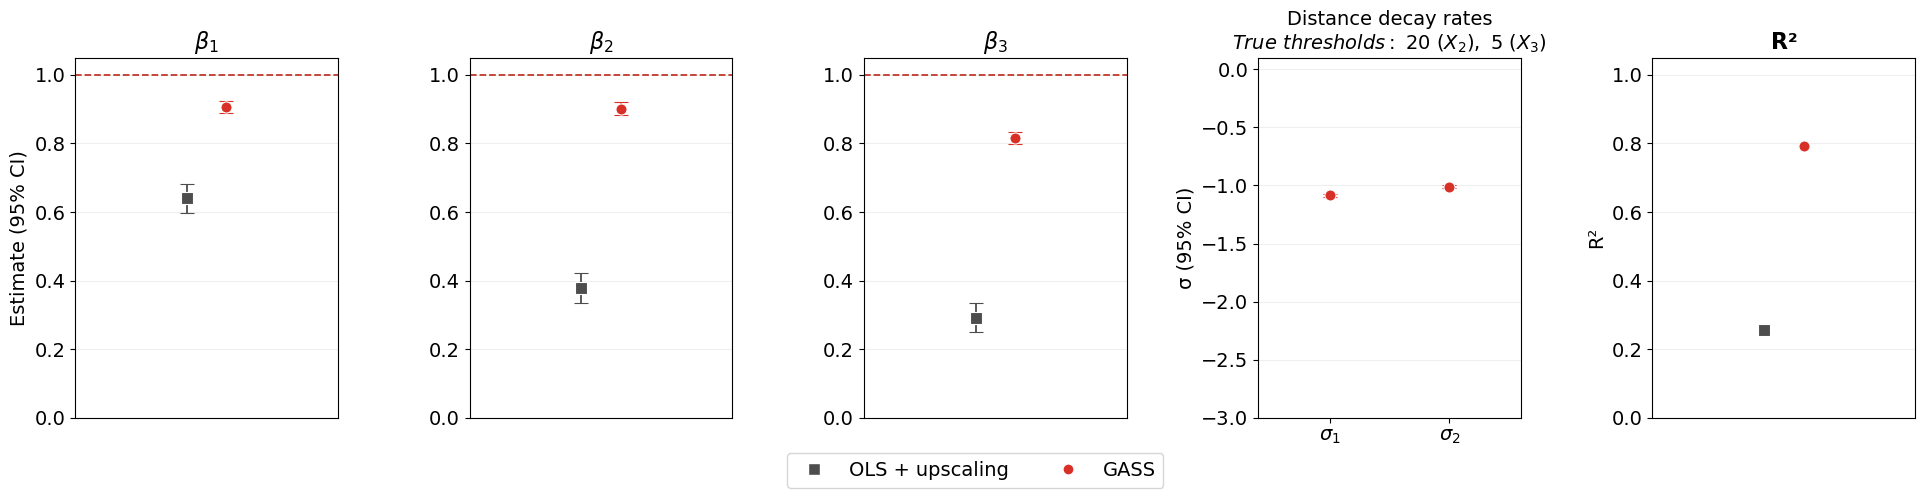

In [81]:
import matplotlib.pyplot as plt
import numpy as np

COL_OLS = '#4D4D4D'
COL_GASS = '#d73027'

ols = {
    'b1': 0.6394, 'b1_lo': 0.5970, 'b1_hi': 0.6819,
    'b2': 0.3783, 'b2_lo': 0.3358, 'b2_hi': 0.4208,
    'b3': 0.2915, 'b3_lo': 0.2491, 'b3_hi': 0.3338,
    'R2': 0.2567,
}

gass = {
    'b1': 0.9062, 'b1_lo': 0.8893, 'b1_hi': 0.9231,
    'b2': 0.9016, 'b2_lo': 0.8827, 'b2_hi': 0.9206,
    'b3': 0.8157, 'b3_lo': 0.7981, 'b3_hi': 0.8334,
    'sig1': -1.0840, 'sig1_lo': -1.1000, 'sig1_hi': -1.0740,
    'sig2': -1.0100, 'sig2_lo': -1.0200, 'sig2_hi': -1.0000,
    'R2': 0.7938,
}

scenarios = [
    ('OLS',  ols,  COL_OLS, 's'),
    ('GASS', gass, COL_GASS, 'o'),
]
offsets = [-0.12, 0.12]

fig, axes = plt.subplots(1, 5, figsize=(20, 5),
                         gridspec_kw={'wspace': 0.50, 'left': 0.05, 'right': 0.97,
                                      'top': 0.86, 'bottom': 0.14})
fig.patch.set_facecolor('none')
ax_b1, ax_b2, ax_b3, ax_sig, ax_r2 = axes

for ax, bk, idx in zip([ax_b1, ax_b2, ax_b3], ['b1','b2','b3'], [1,2,3]):
    ax.set_facecolor('none')
    for i_s, (name, d, col, mkr) in enumerate(scenarios):
        est = d[bk]; lo = d[f'{bk}_lo']; hi = d[f'{bk}_hi']
        yerr = np.array([[est - lo], [hi - est]])
        ax.errorbar([offsets[i_s]], [est], yerr=yerr, fmt=mkr, color=col,
                    markersize=8, markeredgecolor='white', markeredgewidth=0.8,
                    capsize=5, capthick=1.3, linewidth=1.3, elinewidth=1.3,
                    label=name if bk == 'b1' else None, zorder=4)
    ax.axhline(1.0, color='#c0392b', lw=1.3, ls='--', zorder=2)
    ax.set_xlim(-0.8, 0.8); ax.set_ylim(0, 1.05); ax.set_xticks([])
    ax.set_title(fr'$\beta_{{{idx}}}$', fontsize=16, fontweight='bold')
    ax.set_ylabel('Estimate (95% CI)' if idx == 1 else '', fontsize=14)
    ax.tick_params(axis='y', labelsize=14); ax.grid(axis='y', alpha=0.2)

ax_sig.set_facecolor('none')
for j, sk in enumerate(['sig1', 'sig2']):
    est = gass[sk]; lo = gass[f'{sk}_lo']; hi = gass[f'{sk}_hi']
    yerr = np.array([[est - lo], [hi - est]])
    ax_sig.errorbar([j], [est], yerr=yerr, fmt='o', color=COL_GASS,
                    markersize=8, markeredgecolor='white', markeredgewidth=0.8,
                    capsize=5, capthick=1.3, linewidth=1.3, elinewidth=1.3, zorder=4)
ax_sig.set_xticks([0, 1])
ax_sig.set_xticklabels([r'$\sigma_1$', r'$\sigma_2$'], fontsize=14, fontweight='bold')
ax_sig.set_ylim(-3, 0.1); ax_sig.set_xlim(-0.6, 1.6)
ax_sig.set_title('Distance decay rates\n'+r'$\it{True\ thresholds:}\ 20\ (X_2),\ 5\ (X_3)$', fontsize=14)
ax_sig.set_ylabel('σ (95% CI)', fontsize=14)
ax_sig.tick_params(axis='y', labelsize=14); ax_sig.grid(axis='y', alpha=0.2)

# --- R² panel: dots only ---
ax_r2.set_facecolor('none')
for i_s, (name, d, col, mkr) in enumerate(scenarios):
    ax_r2.plot([offsets[i_s]], [d['R2']], marker=mkr, color=col, markersize=8,
               markeredgecolor='white', markeredgewidth=0.8, linewidth=0, zorder=4)
ax_r2.set_xlim(-0.8, 0.8); ax_r2.set_xticks([])
ax_r2.set_ylim(0, 1.05)
ax_r2.set_title('R²', fontsize=16, fontweight='bold')
ax_r2.set_ylabel('R²', fontsize=14)
ax_r2.tick_params(axis='y', labelsize=14); ax_r2.grid(axis='y', alpha=0.2)

handles = [plt.Line2D([0],[0], color=COL_OLS, marker='s', markersize=8, linewidth=0, markeredgecolor='white', label='OLS + upscaling'),
           plt.Line2D([0],[0], color=COL_GASS, marker='o', markersize=8, linewidth=0, markeredgecolor='white', label='GASS')]

leg = fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=14,
                 frameon=True, fancybox=True, bbox_to_anchor=(0.5, -0.02))
leg.get_frame().set_facecolor('none')

plt.savefig("res_ols_vs_gass_p2p.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# a2p

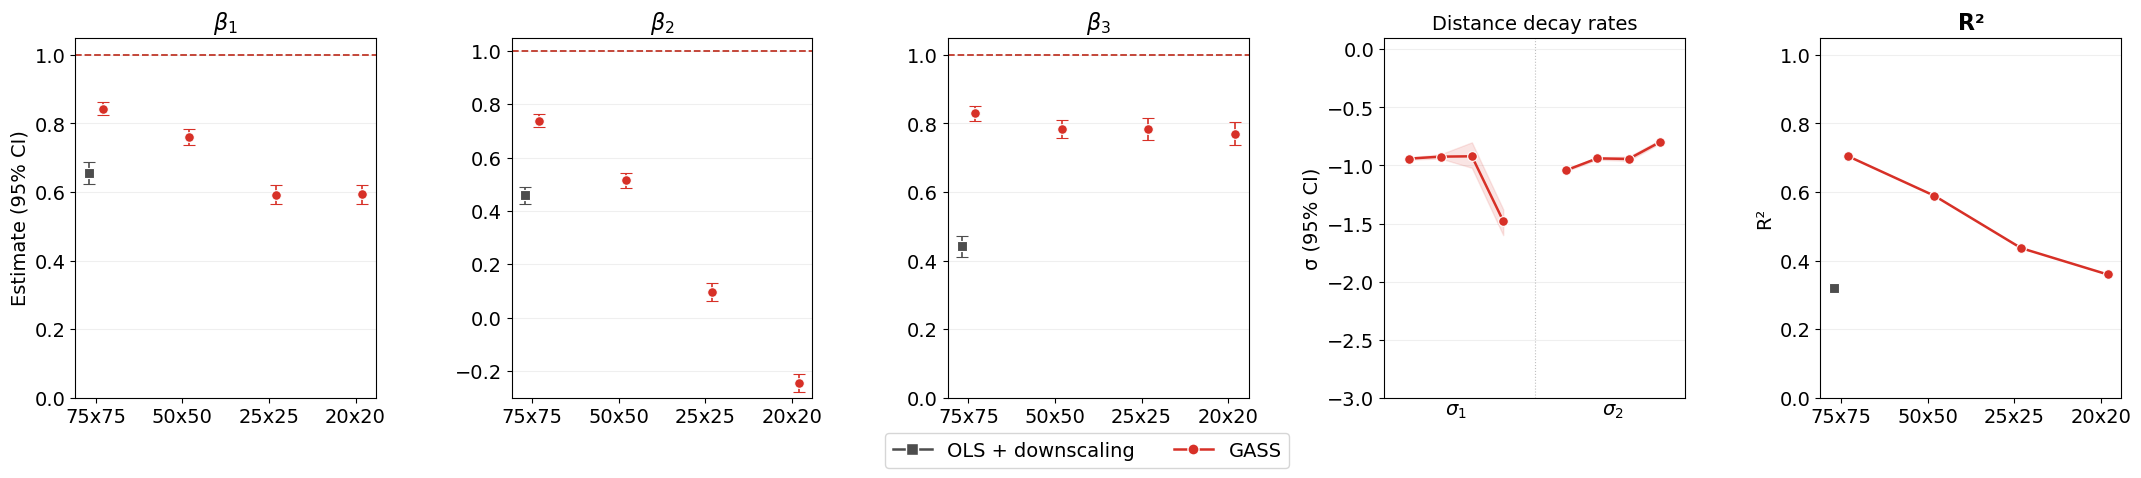

In [86]:
import matplotlib.pyplot as plt
import numpy as np

COL_A2P = '#d73027'
COL_OLS_DS = '#4D4D4D'

zones = ['75x75', '50x50', '25x25', '20x20']
x = np.arange(len(zones))

# --- GASS area-to-point (from first screenshot, dropping 10x10) ---
gass = {
    'b1':    np.array([0.8435, 0.7616, 0.5921, 0.5938]),
    'b1_lo': np.array([0.8232, 0.7381, 0.5651, 0.5662]),
    'b1_hi': np.array([0.8637, 0.7851, 0.6191, 0.6215]),
    'b2':    np.array([0.7394, 0.5149, 0.0965, -0.2461]),
    'b2_lo': np.array([0.7166, 0.4877, 0.0627, -0.2793]),
    'b2_hi': np.array([0.7622, 0.5421, 0.1303, -0.2128]),
    'b3':    np.array([0.8293, 0.7838, 0.7844, 0.7706]),
    'b3_lo': np.array([0.8081, 0.7581, 0.7518, 0.7373]),
    'b3_hi': np.array([0.8504, 0.8095, 0.8171, 0.8039]),
    'sig1':    np.array([-0.9410, -0.9240, -0.9210, -1.4780]),
    'sig1_lo': np.array([-0.9500, -0.9400, -1.0200, -1.6000]),
    'sig1_hi': np.array([-0.9310, -0.9040, -0.8010, -1.3780]),
    'sig2':    np.array([-1.0420, -0.9390, -0.9440, -0.7990]),
    'sig2_lo': np.array([-1.0500, -0.9500, -0.9600, -0.8100]),
    'sig2_hi': np.array([-1.0320, -0.9290, -0.9240, -0.7790]),
    'R2':    np.array([0.7046, 0.5889, 0.4365, 0.3595]),
}

# --- OLS + downscaling (from second screenshot, 75x75 only) ---
ols_ds = {
    'b1': 0.6548, 'b1_lo': 0.6231, 'b1_hi': 0.6866,
    'b2': 0.4592, 'b2_lo': 0.4275, 'b2_hi': 0.4910,
    'b3': 0.4411, 'b3_lo': 0.4095, 'b3_hi': 0.4727,
    'R2': 0.3196,
}

coef_ylims = {'b1': (0, 1.05), 'b2': (-0.3, 1.05), 'b3': (0, 1.05)}
offsets = [-0.08, 0.08]

fig, axes = plt.subplots(1, 5, figsize=(22, 5),
                         gridspec_kw={'wspace': 0.45, 'left': 0.04, 'right': 0.97,
                                      'top': 0.86, 'bottom': 0.14})
fig.patch.set_facecolor('none')
ax_b1, ax_b2, ax_b3, ax_sig, ax_r2 = axes

# --- Coefficient panels ---
for ax, bk, idx in zip([ax_b1, ax_b2, ax_b3], ['b1','b2','b3'], [1,2,3]):
    ax.set_facecolor('none')
    # GASS a2p
    est = gass[bk]; lo = gass[f'{bk}_lo']; hi = gass[f'{bk}_hi']
    yerr = np.vstack([est - lo, hi - est])
    ax.errorbar(x + offsets[1], est, yerr=yerr, fmt='o', color=COL_A2P,
                markersize=7, markeredgecolor='white', markeredgewidth=0.8,
                capsize=4, capthick=1.2, linewidth=1.2, elinewidth=1.2,
                label='GASS' if bk == 'b1' else None, zorder=4)
    # OLS + downscaling (75x75 only)
    est_o = ols_ds[bk]; lo_o = ols_ds[f'{bk}_lo']; hi_o = ols_ds[f'{bk}_hi']
    yerr_o = np.array([[est_o - lo_o], [hi_o - est_o]])
    ax.errorbar([x[0] + offsets[0]], [est_o], yerr=yerr_o, fmt='s', color=COL_OLS_DS,
                markersize=7, markeredgecolor='white', markeredgewidth=0.8,
                capsize=4, capthick=1.2, linewidth=1.2, elinewidth=1.2,
                label='OLS + downscaling' if bk == 'b1' else None, zorder=4)

    ax.axhline(1.0, color='#c0392b', lw=1.3, ls='--', zorder=2)
    ax.set_xticks(x); ax.set_xticklabels(zones, fontsize=14)
    ax.set_ylim(coef_ylims[bk])
    ax.set_title(fr'$\beta_{{{idx}}}$', fontsize=16, fontweight='bold')
    ax.set_ylabel('Estimate (95% CI)' if idx == 1 else '', fontsize=14)
    ax.tick_params(axis='both', labelsize=14); ax.grid(axis='y', alpha=0.2)

# --- Sigma panel (GASS only) ---
ax_sig.set_facecolor('none')
nz = len(zones); sigma_gap = nz + 1
x_s1 = np.arange(nz); x_s2 = np.arange(nz) + sigma_gap
for block_x, sk in zip([x_s1, x_s2], ['sig1','sig2']):
    est = gass[sk]; lo = gass[f'{sk}_lo']; hi = gass[f'{sk}_hi']
    ax_sig.fill_between(block_x, lo, hi, color=COL_A2P, alpha=0.12, zorder=2)
    ax_sig.plot(block_x, est, color=COL_A2P, marker='o', markersize=7, linewidth=1.8,
                markeredgecolor='white', markeredgewidth=0.8, zorder=4)
ax_sig.set_xticks([])
for block_x, sl in zip([x_s1, x_s2], [r'$\sigma_1$', r'$\sigma_2$']):
    ax_sig.text((block_x[0]+block_x[-1])/2, -0.01, sl, ha='center', fontsize=14,
                fontweight='bold', transform=ax_sig.get_xaxis_transform(), va='top')
ax_sig.axvline((x_s1[-1]+x_s2[0])/2, color='grey', lw=0.8, ls=':', alpha=0.5)
ax_sig.set_xlim(x_s1[0]-0.8, x_s2[-1]+0.8)
ax_sig.set_ylim(-3, 0.1)
# ax_sig.set_title('Distance decay rates\n'+r'$\it{True\ thresholds:}\ 20\ (X_2),\ 5\ (X_3)$', fontsize=14)
ax_sig.set_title('Distance decay rates', fontsize=14)

ax_sig.set_ylabel('σ (95% CI)', fontsize=14)
ax_sig.tick_params(axis='y', labelsize=14); ax_sig.grid(axis='y', alpha=0.2)

# --- R² panel ---
ax_r2.set_facecolor('none')
ax_r2.plot(x + offsets[1], gass['R2'], color=COL_A2P, marker='o', markersize=7,
           linewidth=1.8, markeredgecolor='white', markeredgewidth=0.8,
           label='GASS', zorder=4)
ax_r2.plot([x[0] + offsets[0]], [ols_ds['R2']], color=COL_OLS_DS, marker='s', markersize=7,
           linewidth=0, markeredgecolor='white', markeredgewidth=0.8,
           label='OLS + downscaling', zorder=4)
ax_r2.set_xticks(x); ax_r2.set_xticklabels(zones, fontsize=14)
ax_r2.set_ylim(0, 1.05)
ax_r2.set_title('R²', fontsize=16, fontweight='bold')
ax_r2.set_ylabel('R²', fontsize=14)
ax_r2.tick_params(axis='both', labelsize=14); ax_r2.grid(axis='y', alpha=0.2)

# --- Legend ---
handles = [plt.Line2D([0],[0], color=COL_OLS_DS, marker='s', markersize=8, linewidth=1.8, markeredgecolor='white', label='OLS + downscaling'),
           plt.Line2D([0],[0], color=COL_A2P, marker='o', markersize=8, linewidth=1.8, markeredgecolor='white', label='GASS')]

leg = fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=14,
                 frameon=True, fancybox=True, bbox_to_anchor=(0.5, -0.02))
leg.get_frame().set_facecolor('none')

plt.savefig("res_6400_a2p_with_ols_ds.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

# p2a

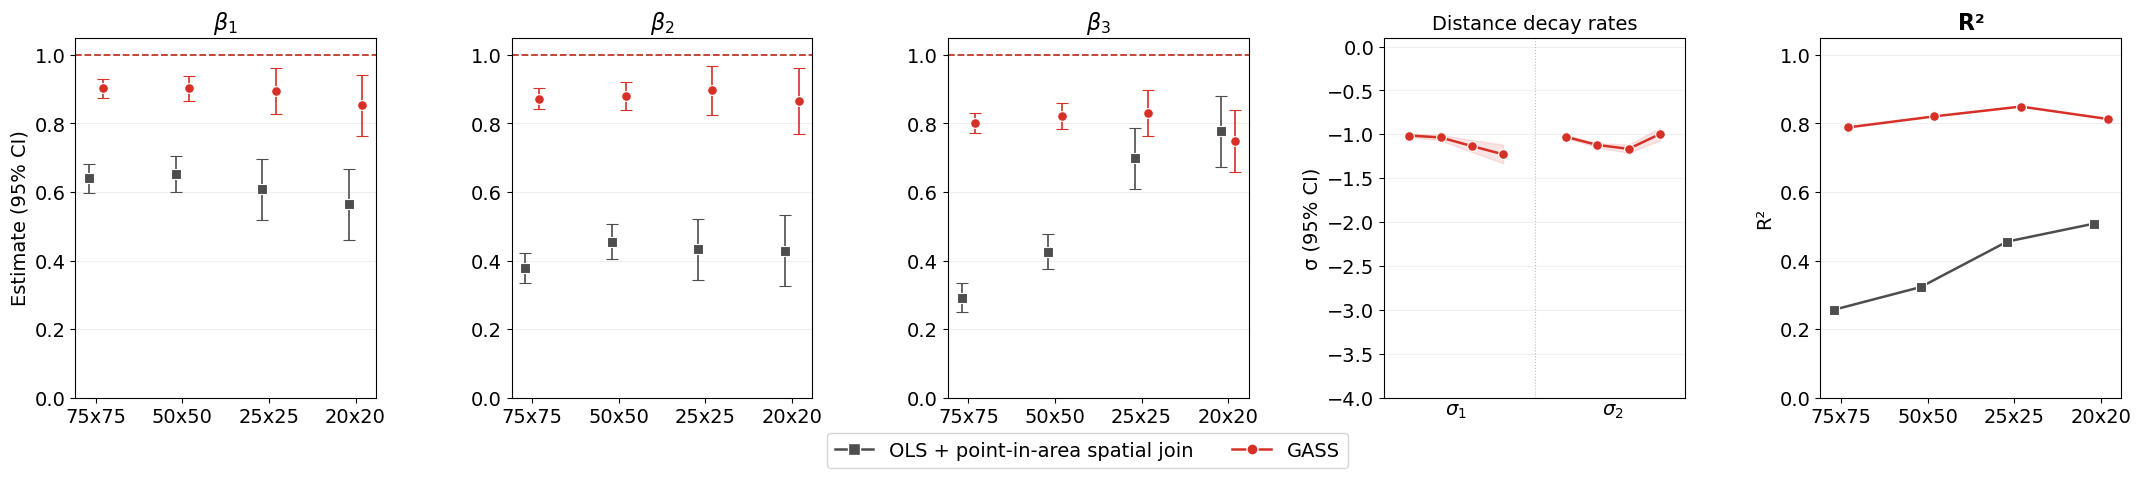

In [88]:
import matplotlib.pyplot as plt
import numpy as np

COL_OLS = '#4D4D4D'
COL_P2A = '#d73027'

zones = ['75x75', '50x50', '25x25', '20x20']
x = np.arange(len(zones))

ols = {
    'b1':    np.array([0.6394, 0.6531, 0.6078, 0.5639]),
    'b1_lo': np.array([0.5970, 0.6014, 0.5195, 0.4596]),
    'b1_hi': np.array([0.6819, 0.7048, 0.6962, 0.6683]),
    'b2':    np.array([0.3783, 0.4556, 0.4329, 0.4289]),
    'b2_lo': np.array([0.3358, 0.4039, 0.3446, 0.3248]),
    'b2_hi': np.array([0.4208, 0.5072, 0.5212, 0.5330]),
    'b3':    np.array([0.2915, 0.4260, 0.6978, 0.7767]),
    'b3_lo': np.array([0.2491, 0.3747, 0.6098, 0.6726]),
    'b3_hi': np.array([0.3338, 0.4773, 0.7858, 0.8809]),
    'R2':    np.array([0.2567, 0.3227, 0.4554, 0.5076]),
}

gass = {
    'b1':    np.array([0.9023, 0.9021, 0.8942, 0.8524]),
    'b1_lo': np.array([0.8742, 0.8655, 0.8280, 0.7634]),
    'b1_hi': np.array([0.9303, 0.9388, 0.9604, 0.9413]),
    'b2':    np.array([0.8723, 0.8805, 0.8968, 0.8648]),
    'b2_lo': np.array([0.8407, 0.8395, 0.8248, 0.7685]),
    'b2_hi': np.array([0.9038, 0.9215, 0.9689, 0.9611]),
    'b3':    np.array([0.8001, 0.8213, 0.8309, 0.7476]),
    'b3_lo': np.array([0.7710, 0.7834, 0.7638, 0.6571]),
    'b3_hi': np.array([0.8293, 0.8592, 0.8981, 0.8380]),
    'sig1':    np.array([-1.0140, -1.0360, -1.1340, -1.2280]),
    'sig1_lo': np.array([-1.0300, -1.0700, -1.2000, -1.3300]),
    'sig1_hi': np.array([-0.9940, -1.0060, -1.0640, -1.1180]),
    'sig2':    np.array([-1.0290, -1.1210, -1.1660, -0.9970]),
    'sig2_lo': np.array([-1.0400, -1.1500, -1.2100, -1.0700]),
    'sig2_hi': np.array([-1.0090, -1.1010, -1.1160, -0.9270]),
    'R2':    np.array([0.7884, 0.8207, 0.8492, 0.8130]),
}

scenarios = [
    ('OLS + point-in-area spatial join',  ols,  COL_OLS, 's'),
    ('GASS', gass, COL_P2A, 'o'),
]
offsets = [-0.08, 0.08]

fig, axes = plt.subplots(1, 5, figsize=(22, 5),
                         gridspec_kw={'wspace': 0.45, 'left': 0.04, 'right': 0.97,
                                      'top': 0.86, 'bottom': 0.14})
fig.patch.set_facecolor('none')
ax_b1, ax_b2, ax_b3, ax_sig, ax_r2 = axes

for ax, bk, idx in zip([ax_b1, ax_b2, ax_b3], ['b1','b2','b3'], [1,2,3]):
    ax.set_facecolor('none')
    for i_s, (name, d, col, mkr) in enumerate(scenarios):
        est = d[bk]; lo = d[f'{bk}_lo']; hi = d[f'{bk}_hi']
        yerr = np.vstack([est - lo, hi - est])
        ax.errorbar(x + offsets[i_s], est, yerr=yerr, fmt=mkr, color=col,
                    markersize=7, markeredgecolor='white', markeredgewidth=0.8,
                    capsize=4, capthick=1.2, linewidth=1.2, elinewidth=1.2,
                    label=name if bk == 'b1' else None, zorder=4)
    ax.axhline(1.0, color='#c0392b', lw=1.3, ls='--', zorder=2)
    ax.set_xticks(x); ax.set_xticklabels(zones, fontsize=14)
    ax.set_ylim(0, 1.05)
    ax.set_title(fr'$\beta_{{{idx}}}$', fontsize=16, fontweight='bold')
    ax.set_ylabel('Estimate (95% CI)' if idx == 1 else '', fontsize=14)
    ax.tick_params(axis='both', labelsize=14); ax.grid(axis='y', alpha=0.2)

ax_sig.set_facecolor('none')
nz = len(zones); sigma_gap = nz + 1
x_s1 = np.arange(nz); x_s2 = np.arange(nz) + sigma_gap
for block_x, sk in zip([x_s1, x_s2], ['sig1','sig2']):
    est = gass[sk]; lo = gass[f'{sk}_lo']; hi = gass[f'{sk}_hi']
    ax_sig.fill_between(block_x, lo, hi, color=COL_P2A, alpha=0.12, zorder=2)
    ax_sig.plot(block_x, est, color=COL_P2A, marker='o', markersize=7, linewidth=1.8,
                markeredgecolor='white', markeredgewidth=0.8, zorder=4)
ax_sig.set_xticks([])
for block_x, sl in zip([x_s1, x_s2], [r'$\sigma_1$', r'$\sigma_2$']):
    ax_sig.text((block_x[0]+block_x[-1])/2, -0.01, sl, ha='center', fontsize=14,
                fontweight='bold', transform=ax_sig.get_xaxis_transform(), va='top')
ax_sig.axvline((x_s1[-1]+x_s2[0])/2, color='grey', lw=0.8, ls=':', alpha=0.5)
ax_sig.set_xlim(x_s1[0]-0.8, x_s2[-1]+0.8)
ax_sig.set_ylim(-4, 0.1)
# ax_sig.set_title('Distance decay rates\n'+r'$\it{True\ thresholds:}\ 20\ (X_2),\ 5\ (X_3)$', fontsize=14)
ax_sig.set_title('Distance decay rates', fontsize=14)
ax_sig.set_ylabel('σ (95% CI)', fontsize=14)
ax_sig.tick_params(axis='y', labelsize=14); ax_sig.grid(axis='y', alpha=0.2)

ax_r2.set_facecolor('none')
for i_s, (name, d, col, mkr) in enumerate(scenarios):
    ax_r2.plot(x + offsets[i_s], d['R2'], color=col, marker=mkr, markersize=7,
               linewidth=1.8, markeredgecolor='white', markeredgewidth=0.8, label=name, zorder=4)
ax_r2.set_xticks(x); ax_r2.set_xticklabels(zones, fontsize=14)
ax_r2.set_ylim(0, 1.05)
ax_r2.set_title('R²', fontsize=16, fontweight='bold')
ax_r2.set_ylabel('R²', fontsize=14)
ax_r2.tick_params(axis='both', labelsize=14); ax_r2.grid(axis='y', alpha=0.2)

handles = [plt.Line2D([0],[0], color=COL_OLS, marker='s', markersize=8, linewidth=1.8, markeredgecolor='white', label='OLS + point-in-area spatial join'),
           plt.Line2D([0],[0], color=COL_P2A, marker='o', markersize=8, linewidth=1.8, markeredgecolor='white', label='GASS')]
leg = fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=14,
                 frameon=True, fancybox=True, bbox_to_anchor=(0.5, -0.02))
leg.get_frame().set_facecolor('none')

plt.savefig("res_6400_ols_p2a.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

# a2a

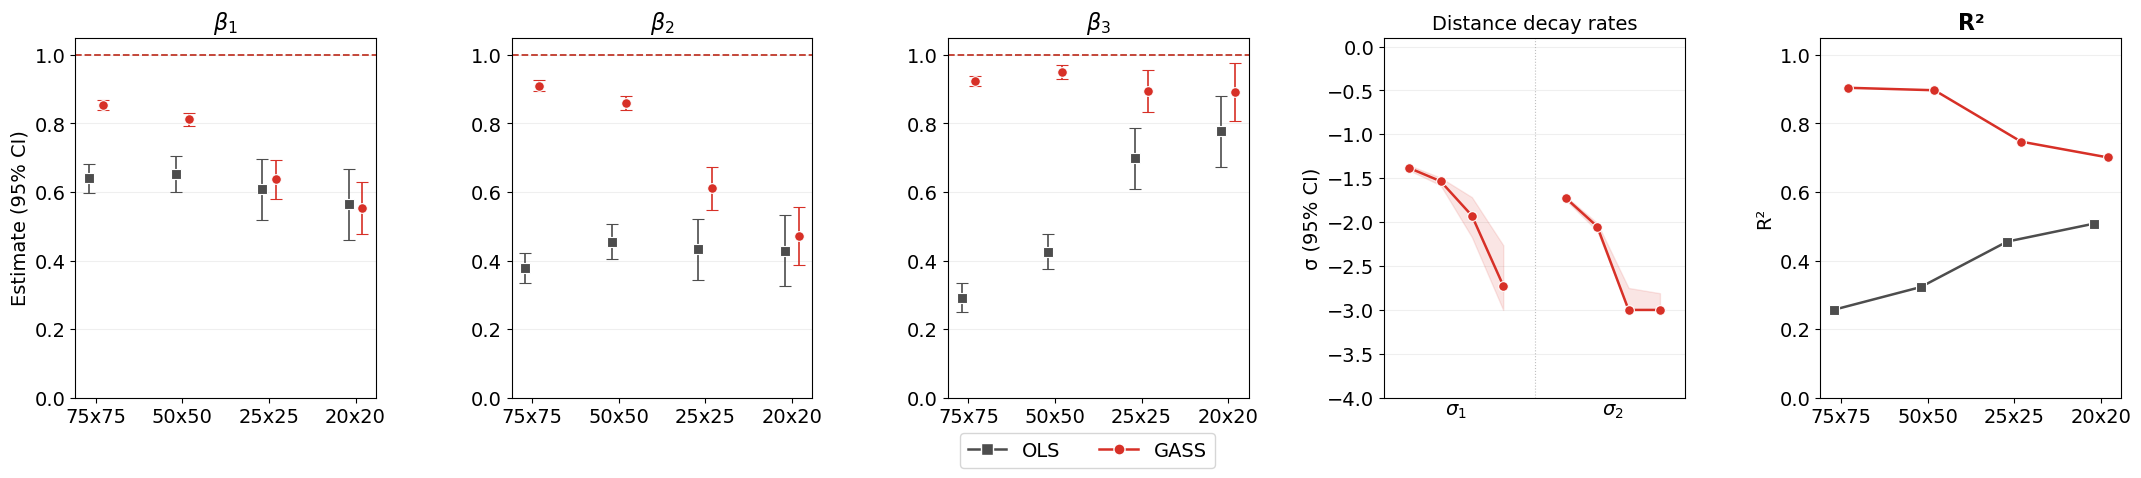

In [89]:
import matplotlib.pyplot as plt
import numpy as np

COL_OLS = '#4D4D4D'
COL_A2A = '#d73027'

zones = ['75x75', '50x50', '25x25', '20x20']
x = np.arange(len(zones))

ols = {
    'b1':    np.array([0.6394, 0.6531, 0.6078, 0.5639]),
    'b1_lo': np.array([0.5970, 0.6014, 0.5195, 0.4596]),
    'b1_hi': np.array([0.6819, 0.7048, 0.6962, 0.6683]),
    'b2':    np.array([0.3783, 0.4556, 0.4329, 0.4289]),
    'b2_lo': np.array([0.3358, 0.4039, 0.3446, 0.3248]),
    'b2_hi': np.array([0.4208, 0.5072, 0.5212, 0.5330]),
    'b3':    np.array([0.2915, 0.4260, 0.6978, 0.7767]),
    'b3_lo': np.array([0.2491, 0.3747, 0.6098, 0.6726]),
    'b3_hi': np.array([0.3338, 0.4773, 0.7858, 0.8809]),
    'R2':    np.array([0.2567, 0.3227, 0.4554, 0.5076]),
}

gass = {
    'b1':    np.array([0.8551, 0.8115, 0.6371, 0.5537]),
    'b1_lo': np.array([0.8404, 0.7924, 0.5807, 0.4785]),
    'b1_hi': np.array([0.8698, 0.8306, 0.6935, 0.6288]),
    'b2':    np.array([0.9095, 0.8594, 0.6110, 0.4718]),
    'b2_lo': np.array([0.8932, 0.8380, 0.5479, 0.3866]),
    'b2_hi': np.array([0.9259, 0.8808, 0.6742, 0.5570]),
    'b3':    np.array([0.9238, 0.9503, 0.8958, 0.8920]),
    'b3_lo': np.array([0.9085, 0.9301, 0.8347, 0.8078]),
    'b3_hi': np.array([0.9391, 0.9704, 0.9570, 0.9763]),
    'sig1':    np.array([-1.3840, -1.5340, -1.9260, -2.7230]),
    'sig1_lo': np.array([-1.4100, -1.5800, -2.1700, -3.0000]),
    'sig1_hi': np.array([-1.3540, -1.4940, -1.7160, -2.2630]),
    'sig2':    np.array([-1.7270, -2.0500, -3.0000, -3.0000]),
    'sig2_lo': np.array([-1.7500, -2.1000, -3.0000, -3.0000]),
    'sig2_hi': np.array([-1.7070, -2.0100, -2.7500, -2.8100]),
    'R2':    np.array([0.9040, 0.8968, 0.7470, 0.7010]),
}

scenarios = [
    ('OLS', ols, COL_OLS, 's'),
    ('GASS', gass, COL_A2A, 'o'),
]
offsets = [-0.08, 0.08]

fig, axes = plt.subplots(1, 5, figsize=(22, 5),
                         gridspec_kw={'wspace': 0.45, 'left': 0.04, 'right': 0.97,
                                      'top': 0.86, 'bottom': 0.14})
fig.patch.set_facecolor('none')
ax_b1, ax_b2, ax_b3, ax_sig, ax_r2 = axes

for ax, bk, idx in zip([ax_b1, ax_b2, ax_b3], ['b1','b2','b3'], [1,2,3]):
    ax.set_facecolor('none')
    for i_s, (name, d, col, mkr) in enumerate(scenarios):
        est = d[bk]; lo = d[f'{bk}_lo']; hi = d[f'{bk}_hi']
        yerr = np.vstack([est - lo, hi - est])
        ax.errorbar(x + offsets[i_s], est, yerr=yerr, fmt=mkr, color=col,
                    markersize=7, markeredgecolor='white', markeredgewidth=0.8,
                    capsize=4, capthick=1.2, linewidth=1.2, elinewidth=1.2,
                    label=name if bk == 'b1' else None, zorder=4)
    ax.axhline(1.0, color='#c0392b', lw=1.3, ls='--', zorder=2)
    ax.set_xticks(x); ax.set_xticklabels(zones, fontsize=14)
    ax.set_ylim(0, 1.05)
    ax.set_title(fr'$\beta_{{{idx}}}$', fontsize=16, fontweight='bold')
    ax.set_ylabel('Estimate (95% CI)' if idx == 1 else '', fontsize=14)
    ax.tick_params(axis='both', labelsize=14); ax.grid(axis='y', alpha=0.2)

ax_sig.set_facecolor('none')
nz = len(zones); sigma_gap = nz + 1
x_s1 = np.arange(nz); x_s2 = np.arange(nz) + sigma_gap
for block_x, sk in zip([x_s1, x_s2], ['sig1','sig2']):
    est = gass[sk]; lo = gass[f'{sk}_lo']; hi = gass[f'{sk}_hi']
    ax_sig.fill_between(block_x, lo, hi, color=COL_A2A, alpha=0.12, zorder=2)
    ax_sig.plot(block_x, est, color=COL_A2A, marker='o', markersize=7, linewidth=1.8,
                markeredgecolor='white', markeredgewidth=0.8, zorder=4)
ax_sig.set_xticks([])
for block_x, sl in zip([x_s1, x_s2], [r'$\sigma_1$', r'$\sigma_2$']):
    ax_sig.text((block_x[0]+block_x[-1])/2, -0.01, sl, ha='center', fontsize=14,
                fontweight='bold', transform=ax_sig.get_xaxis_transform(), va='top')
ax_sig.axvline((x_s1[-1]+x_s2[0])/2, color='grey', lw=0.8, ls=':', alpha=0.5)
ax_sig.set_xlim(x_s1[0]-0.8, x_s2[-1]+0.8)
ax_sig.set_ylim(-4, 0.1)
ax_sig.set_title('Distance decay rates', fontsize=14)
ax_sig.set_ylabel('σ (95% CI)', fontsize=14)
ax_sig.tick_params(axis='y', labelsize=14); ax_sig.grid(axis='y', alpha=0.2)

ax_r2.set_facecolor('none')
for i_s, (name, d, col, mkr) in enumerate(scenarios):
    ax_r2.plot(x + offsets[i_s], d['R2'], color=col, marker=mkr, markersize=7,
               linewidth=1.8, markeredgecolor='white', markeredgewidth=0.8, label=name, zorder=4)
ax_r2.set_xticks(x); ax_r2.set_xticklabels(zones, fontsize=14)
ax_r2.set_ylim(0, 1.05)
ax_r2.set_title('R²', fontsize=16, fontweight='bold')
ax_r2.set_ylabel('R²', fontsize=14)
ax_r2.tick_params(axis='both', labelsize=14); ax_r2.grid(axis='y', alpha=0.2)

handles = [plt.Line2D([0],[0], color=COL_OLS, marker='s', markersize=8, linewidth=1.8, markeredgecolor='white', label='OLS'),
           plt.Line2D([0],[0], color=COL_A2A, marker='o', markersize=8, linewidth=1.8, markeredgecolor='white', label='GASS')]

leg = fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=14,
                 frameon=True, fancybox=True, bbox_to_anchor=(0.5, -0.02))
leg.get_frame().set_facecolor('none')

plt.savefig("res_6400_ols_a2a.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()